# Pricing US Flood Risk at underwriting

### SMM284 Applied Machine Learning Group 09


## 1. Setup

Formatter: `Black`


In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn import set_config
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

# keep the notebook output clean
warnings.filterwarnings("ignore")
# show pipelines as diagrams
set_config(display="diagram")
# group 09 (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧
RANDOM_STATE = 9
plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.max_columns", 40)
print("setup done")

setup done


In [298]:
# freeze environment -> requirements.txt
# (install with `pip install -r requirements.txt`)
import subprocess
import sys

# get exact Python executable running this notebook
python_exe = sys.executable

# -> pip freeze using this specific Python executable
result = subprocess.run(
    [python_exe, "-m", "pip", "freeze"], capture_output=True, text=True
)

# write to requirements.txt
with open("requirements.txt", "w") as f:
    f.write(result.stdout)

print("> requirements.txt generated.")

> requirements.txt generated.


## 2. Data acquisition - Federal Emergency Management Agency (FEMA) OpenFEMA (National Flood Insurance Program [NFIP] claims)

_See https://www.fema.gov/openfema-data-page/fima-nfip-redacted-policies-v2 for
additional background information_


In [299]:
# Data acquisition
# Source: FEMA OpenFEMA "FIMA NFIP Redacted Claims" v2
# (~2.72M rows, refreshed ~monthly). The metadata API is used only for the
# dataset descriptor and field schema. The records come from the bulk parquet,
# downloaded once and cached under data/raw/ with a 'provenance sidecar'.
#
# BE note: only learned the term provenance sidecar through this project
#   "a provenance sidecar is a specialized design pattern used to track and 
#   verify the history of software artifacts without burdening the application 
#   code itself."
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import requests

# --- Endpoints -------------------------------------------------------------
METADATA_BASE = "https://www.fema.gov/api/open/v1"
DATA_API = "https://www.fema.gov/api/open/v2/FimaNfipClaims"
DATASET_NAME = "FimaNfipClaims"
DATASET_VERSION = 2

RAW_DIR = Path("data/raw")
RAW_PARQUET = RAW_DIR / "FimaNfipClaimsV2.parquet"
PROVENANCE = RAW_DIR / "provenance.json"

# --- Column contract (the leakage boundary) --------------------------------
TARGET = "amountPaidOnBuildingClaim"

# Known at underwriting time -> legal features for a pricing model
UNDERWRITING_FEATURES = [
    "ratedFloodZone",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "elevatedBuildingIndicator",
    "basementEnclosureCrawlspaceType",
    "obstructionType",
    "occupancyType",
    "numberOfFloorsInTheInsuredBuilding",
    "buildingDescriptionCode",
    "condominiumCoverageTypeCode",
    "postFIRMConstructionIndicator",
    "originalConstructionDate",
    "primaryResidenceIndicator",
    "rentalPropertyIndicator",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "buildingDeductibleCode",
    "crsClassificationCode",
    "elevationCertificateIndicator",
]

# Known only after the flood -> leakage for a pricing model
# can't use as features
# BE note: this dataset contains just flooded properties, but some have a 0
# claim amount
POST_FLOOD_FIELDS = [
    "waterDepth",
    "floodWaterDuration",
    "floodCharacteristicsIndicator",
    "causeOfDamage",
    "floodEvent",
    "eventDesignationNumber",
    "ficoNumber",
    "buildingDamageAmount",
    "contentsDamageAmount",
    "amountPaidOnContentsClaim",
    "netBuildingPaymentAmount",
    "netContentsPaymentAmount",
    "replacementCostBasis",
    "nonPaymentReasonBuilding",
    "nonPaymentReasonContents",
]

# Geography + time for EDA
# includes the zone/state baseline, and grouped CV splits
CONTEXT = [
    "state",
    "countyCode",
    "yearOfLoss",
    "dateOfLoss",
    "latitude",
    "longitude",
]

# Diagnostic fields for the under-insurance rider (not pricing features)
RIDER = ["buildingReplacementCost", "buildingPropertyValue"]

# what to load from parquet
# (target + legal features + context + rider)
LOAD_COLUMNS = [TARGET] + UNDERWRITING_FEATURES + CONTEXT + RIDER


# --- Metadata API ----------------------------------------------------------
def _get_json(path: str, params: dict) -> dict:
    """GET a small OpenFEMA metadata payload as JSON."""
    resp = requests.get(f"{METADATA_BASE}/{path}", params=params, timeout=60)
    resp.raise_for_status()
    return resp.json()


def get_dataset_metadata() -> dict:
    """Dataset descriptor: bulk file URLs, record count, refresh stamp, hash."""
    payload = _get_json("OpenFemaDataSets", {"$filter": f"name eq '{DATASET_NAME}'"})
    ds = payload["OpenFemaDataSets"][0]
    dist = {d["format"]: d["accessURL"] for d in ds["distribution"]}
    return {
        "record_count": ds["recordCount"],
        "parquet_url": dist["parquet"],
        "csv_url": dist["csv"],
        "last_refresh": ds["lastDataSetRefresh"],
        "hash": ds["hash"],
        "version": ds["version"],
    }


def get_field_schema() -> pd.DataFrame:
    """Field dictionary as a DataFrame (name, type, description, key, nullable)."""
    payload = _get_json(
        "OpenFemaDataSetFields",
        {
            "$filter": f"openFemaDataSet eq '{DATASET_NAME}' "
            f"and datasetVersion eq {DATASET_VERSION}"
        },
    )
    fields = pd.DataFrame(payload["OpenFemaDataSetFields"])
    return fields[["name", "type", "description", "primaryKey", "isNullable"]]


# --- Bulk download + load --------------------------------------------------
def download_raw(force: bool = False) -> Path:
    """Download the bulk Parquet once into data/raw/; skip if already cached.

    Writes a provenance.json sidecar (source URL, FEMA hash, expected row
    count, download time) so the run is reproducible and auditable.
    """
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    if RAW_PARQUET.exists() and not force:
        return RAW_PARQUET

    meta = get_dataset_metadata()
    print(f"Downloading bulk parquet (~50-500 MB):\n  {meta['parquet_url']}")
    with requests.get(meta["parquet_url"], stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(RAW_PARQUET, "wb") as fh:
            for chunk in r.iter_content(chunk_size=1 << 20):  # 1 MB chunks
                fh.write(chunk)

    PROVENANCE.write_text(
        json.dumps(
            {
                "parquet_url": meta["parquet_url"],
                "fema_hash": meta["hash"],
                "expected_record_count": meta["record_count"],
                "last_refresh": meta["last_refresh"],
                "downloaded_at": datetime.now(timezone.utc).isoformat(),
            },
            indent=2,
        )
    )
    print(f"Saved -> {RAW_PARQUET}")
    return RAW_PARQUET


def load_raw(
    columns: list[str] | None = LOAD_COLUMNS, validate: bool = True
) -> pd.DataFrame:
    """Load the cached Parquet (default: the project's ~30 columns via pushdown).

    Pass columns=None to load all 73 fields. Row count is checked against the
    recorded provenance as a soft warning (FEMA refreshes monthly, so a drift
    is informative, not an error).
    """
    path = download_raw()
    df = pd.read_parquet(path, columns=columns, engine="pyarrow")

    if validate and PROVENANCE.exists():
        expected = json.loads(PROVENANCE.read_text())["expected_record_count"]
        if len(df) != expected:
            print(
                f"NOTE: loaded {len(df):,} rows; provenance expected "
                f"{expected:,}. FEMA likely refreshed the file — "
                f"re-run download_raw(force=True) to re-pin provenance."
            )
    return df


# --- Small API slice (for quick dev / building the shared fixture) ---------
def fetch_api_sample(n: int = 1000, where: str | None = None) -> pd.DataFrame:
    """Pull up to n rows via the v2 data API (paged in 1,000s).

    Use for fast iteration or to build the committed dev fixture, e.g.
    fetch_api_sample(2000, where="state eq 'TX' and yearOfLoss eq 2017").
    Do NOT use this to assemble the full dataset — use the bulk parquet.
    """
    rows, skip, page = [], 0, min(n, 1000)
    while len(rows) < n:
        params = {"$top": page, "$skip": skip, "$format": "json"}
        if where:
            params["$filter"] = where
        resp = requests.get(DATA_API, params=params, timeout=120)
        resp.raise_for_status()
        batch = resp.json().get(DATASET_NAME, [])
        if not batch:
            break
        rows.extend(batch)
        skip += page
    return pd.DataFrame(rows[:n])

In [300]:
# Sample fixture
#   cut a small, representative parquet slice for fast testing
# Stratified by state x decade, with the known edge cases forced in so every
# cleaning code path is exercised even on the small slice.
# Note: Building it requires the full parquet (downloaded if absent).
SAMPLE_PARQUET = Path("data/sample/nfip_sample.parquet")


def build_sample(target_rows: int = 30_000, seed: int = 284) -> Path:
    """Build the committed sample slice from the full parquet."""
    SAMPLE_PARQUET.parent.mkdir(parents=True, exist_ok=True)
    # all cols, including 'id'
    full = pd.read_parquet(download_raw(), engine="pyarrow")
    print(f"full: {len(full):,} rows x {full.shape[1]} cols")

    # Strata key as a standalone Series
    #   -> never added to full, nothing to drop later
    decade = pd.to_numeric(full["yearOfLoss"], errors="coerce") // 10 * 10
    strata_key = (
        full["state"].astype("string").fillna("NA")
        + "_"
        + decade.astype("string").fillna("NA")
    )

    frac = min(1.0, target_rows / len(full))

    # Proportional sample per stratum, min 1 per group
    # group_keys=False keeps it flat
    sample = (
        full.groupby(strata_key, group_keys=False)
        .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=seed))
        .reset_index(drop=True)
    )

    # Guarantee the known edge cases are present (don't rely on luck)
    def force_in(sample, mask, n, label):
        extra = full.loc[mask]
        if len(extra):
            add = extra.sample(min(n, len(extra)), random_state=seed)
            sample = pd.concat([sample, add]).drop_duplicates(subset="id")
            print(f"  +{min(n, len(extra))} {label}")
        return sample

    bld = pd.to_numeric(full["amountPaidOnBuildingClaim"], errors="coerce")
    sample = force_in(sample, bld < 0, 50, "negative payouts")
    sample = force_in(sample, bld == 0, 200, "zero/denied payouts")
    sample = force_in(
        sample,
        pd.to_numeric(full["baseFloodElevation"], errors="coerce").abs() >= 9990,
        100,
        "BFE sentinel codes",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["elevationDifference"], errors="coerce").abs() >= 90,
        100,
        "elevationDifference code families / sentinel arithmetic",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["occupancyType"], errors="coerce") >= 11,
        200,
        "Risk Rating 2.0 codes",
    )
    sample = force_in(
        sample,
        pd.to_numeric(full["yearOfLoss"], errors="coerce") < 1996,
        200,
        "pre-1996 records",
    )

    # shuffle
    sample = sample.sample(frac=1, random_state=seed).reset_index(drop=True)
    sample.to_parquet(SAMPLE_PARQUET, engine="pyarrow", compression="zstd")

    prov = json.loads(PROVENANCE.read_text()) if PROVENANCE.exists() else {}
    SAMPLE_PARQUET.with_suffix(".provenance.json").write_text(
        json.dumps(
            {
                "built_from_raw_hash": prov.get("fema_hash"),
                "raw_last_refresh": prov.get("last_refresh"),
                "built_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                "rows": int(len(sample)),
            },
            indent=2,
        )
    )

    mb = SAMPLE_PARQUET.stat().st_size / 1e6
    print(
        f"wrote {SAMPLE_PARQUET}: {len(sample):,} rows x {sample.shape[1]} cols, {mb:.2f} MB"
    )
    if mb > 3.0:
        print("Above ~3 MB — re-run with target_rows=15_000 (zstd already on).")
    return SAMPLE_PARQUET

In [301]:
# --- data selection toggle ---------------------------------------------------
# True  -> ~30k-row representative slice: fast, for testing the pipeline
#          end-to-end before leaving the tuning to run
# False -> full dataset (~2.7M rows): the real run
USE_SAMPLE = False

# BE note: at Bayes library the full download takes ~15.4 seconds

if USE_SAMPLE:
    if not SAMPLE_PARQUET.exists():
        # blank directory: builds the slice 
        # (downloads the full parquet first if it is also missing)
        build_sample()
    DATA_PATH = SAMPLE_PARQUET
else:
    download_raw()  # no-op if already cached
    DATA_PATH = RAW_PARQUET

# same column pushdown for both, so df has an identical shape in either mode
df = pd.read_parquet(DATA_PATH, columns=LOAD_COLUMNS, engine="pyarrow")

mode = "SAMPLE (testing)" if USE_SAMPLE else "FULL"
print(
    f"mode: {mode}   loaded {DATA_PATH}  ->  rows: {len(df):,}   columns: {df.shape[1]}"
)
df.head(3)

mode: FULL   loaded data/raw/FimaNfipClaimsV2.parquet  ->  rows: 2,721,780   columns: 30


,amountPaidOnBuildingClaim,ratedFloodZone,elevationDifference,baseFloodElevation,lowestFloorElevation,lowestAdjacentGrade,elevatedBuildingIndicator,basementEnclosureCrawlspaceType,obstructionType,occupancyType,numberOfFloorsInTheInsuredBuilding,buildingDescriptionCode,condominiumCoverageTypeCode,postFIRMConstructionIndicator,originalConstructionDate,primaryResidenceIndicator,rentalPropertyIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,buildingDeductibleCode,crsClassificationCode,elevationCertificateIndicator,state,countyCode,yearOfLoss,dateOfLoss,latitude,longitude,buildingReplacementCost,buildingPropertyValue
0,7243.04,A07,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1970-07-01,False,False,59700.0,8800.0,1,NaN,NaN,NJ,34025,1992,1992-12-11,40.4,-74.0,0.0,24400.0
1,39008.35,AE,6.0,7.4,0.0,0.0,True,NaN,15.0,11.0,2.0,1.0,N,False,1982-01-01,False,False,250000.0,21000.0,F,NaN,NaN,FL,12037,2018,2018-10-10,29.7,-84.9,299144.0,257264.0
2,None,A17,None,None,None,None,False,2.0,10.0,1.0,2.0,NaN,N,False,1959-07-01,False,False,176000.0,50000.0,1,NaN,NaN,PA,42091,1996,1996-12-16,40.1,-75.4,NaN,NaN


In [302]:
schema = get_field_schema()  # name / type / description / key / nullable
schema.head()

,name,type,description,primaryKey,isNullable
0,asOfDate,datetime,The effective date of the data in the file. In...,False,True
1,amountPaidOnBuildingClaim,"decimal(12,2)",Dollar amount paid on the building claim. In s...,False,True
2,amountPaidOnContentsClaim,"decimal(12,2)",Dollar amount paid on the contents claim. In s...,False,True
3,amountPaidOnIncreasedCostOfComplianceClaim,"decimal(12,2)",ICC coverage is one of several flood insurance...,False,True
4,netBuildingPaymentAmount,"decimal(12,2)",Net building payment amount made to insured in...,False,True


## 3. Initial look


In [303]:
display(df.dtypes)
# sparsest columns first
df.isna().mean().sort_values(ascending=False).head(20)

amountPaidOnBuildingClaim              object
ratedFloodZone                            str
elevationDifference                    object
baseFloodElevation                     object
lowestFloorElevation                   object
lowestAdjacentGrade                    object
elevatedBuildingIndicator                bool
basementEnclosureCrawlspaceType       float64
obstructionType                       float64
occupancyType                         float64
numberOfFloorsInTheInsuredBuilding    float64
buildingDescriptionCode               float64
condominiumCoverageTypeCode               str
postFIRMConstructionIndicator            bool
originalConstructionDate               object
primaryResidenceIndicator                bool
rentalPropertyIndicator                  bool
totalBuildingInsuranceCoverage        float64
totalContentsInsuranceCoverage        float64
buildingDeductibleCode                    str
crsClassificationCode                 float64
elevationCertificateIndicator     

crsClassificationCode                 0.949849
lowestAdjacentGrade                   0.810814
elevationCertificateIndicator         0.779866
lowestFloorElevation                  0.763696
baseFloodElevation                    0.756969
elevationDifference                   0.729864
basementEnclosureCrawlspaceType       0.697886
buildingDescriptionCode               0.639162
obstructionType                       0.444430
buildingReplacementCost               0.219006
buildingPropertyValue                 0.218964
amountPaidOnBuildingClaim             0.208081
buildingDeductibleCode                0.098972
ratedFloodZone                        0.051081
countyCode                            0.022942
longitude                             0.015225
latitude                              0.015225
condominiumCoverageTypeCode           0.013760
numberOfFloorsInTheInsuredBuilding    0.006337
originalConstructionDate              0.000730
dtype: float64

count     2155429
unique    1357994
top          0.00
freq       150348
Name: amountPaidOnBuildingClaim, dtype: object
zero payouts: 5.5%
negative payouts: 86


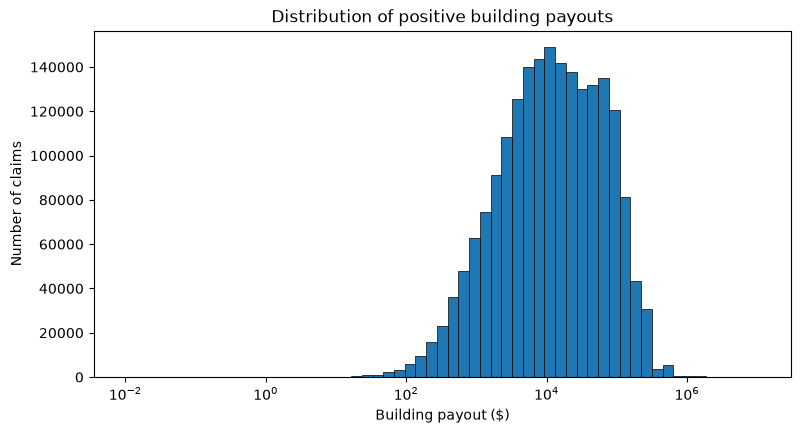

In [304]:
print(df[TARGET].describe())
# denied / no building payment
print(f"zero payouts: {(df[TARGET] == 0).mean():.1%}")
# re-issued cheques
print(f"negative payouts: {(df[TARGET] < 0).sum():,}")

# positive payouts
pos = df[df[TARGET] > 0][TARGET].astype(float)
# calc bins and counts using numpy (faster)
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 60)
counts, edges = np.histogram(pos, bins=bins)
# plt.stairs(counts, edges, fill=True)
plt.bar(
    x=edges[:-1],
    height=counts,
    width=np.diff(edges),
    align="edge",
    edgecolor="black",
    linewidth=0.5,
)
plt.xscale("log")
plt.xlabel("Building payout ($)")
plt.ylabel("Number of claims")
plt.title("Distribution of positive building payouts")
plt.show()

In [305]:
# Debug check for elevationDifference code families, kept for reference
# self-contained 
#   reads the single column itself (cheap), so it doesn't depend on the 
#   verification cell above, which deletes `full` after use
if RAW_PARQUET.exists():
    v = pd.to_numeric(
        pd.read_parquet(
            RAW_PARQUET, columns=["elevationDifference"], engine="pyarrow"
        )["elevationDifference"],
        errors="coerce",
    )
    print(f"{(v.abs() >= 90).sum():,} rows nulled in total by the >= 90 rule")
    print(f"{((v.abs() >= 90) & (v.abs() < 900)).sum():,} of those sit between 90 and 900")
    # full distribution (very verbose) — uncomment only when investigating:
    # print(v[v.abs().between(50, 9990)].round(0).value_counts().sort_index().to_string())
    del v
else:
    print("full parquet not cached — debug check skipped")

661 rows nulled in total by the >= 90 rule
616 of those sit between 90 and 900


In [306]:
# check for missing values where "9999" was entered to show it was missing
for col in ["elevationDifference", "baseFloodElevation"]:
    is_sentinel = pd.to_numeric(df[col], errors="coerce").abs() >= 9990
    print(f"{col} sentinel (±9999): {is_sentinel.sum():,} ({is_sentinel.mean():.1%})")


print("\nOccupancy Type:")
print(df["occupancyType"].value_counts().head(12).apply(lambda x: f"{x:,}"))
# 1-digit legacy vs 2-digit Risk Rating 2.0
print(df["ratedFloodZone"].value_counts().head(12).apply(lambda x: f"{x:,}"))

elevationDifference sentinel (±9999): 0 (0.0%)
baseFloodElevation sentinel (±9999): 3,371 (0.1%)

Occupancy Type:
occupancyType
1.0     1,793,554
11.0      414,893
4.0       170,158
2.0       130,077
3.0        79,118
18.0       36,948
15.0       24,434
6.0        23,703
12.0       19,640
16.0       10,671
14.0        9,443
13.0        8,207
Name: count, dtype: str
ratedFloodZone
AE     939,766
X      406,706
A      201,560
C      164,158
B      115,181
A04     51,876
A01     51,408
A05     48,604
VE      47,935
A06     47,105
A08     45,756
A07     43,730
Name: count, dtype: str


In [307]:
# sentinel verification against the full parquet (all 2.7M rows)
# intentionally bypasses the sample toggle 
# Want to check raw snapshot so this will only run when the full file is cached
if RAW_PARQUET.exists():
    cols = [
        "elevationDifference",
        "baseFloodElevation",
        "lowestFloorElevation",
        "lowestAdjacentGrade",
    ]
    full = pd.read_parquet(RAW_PARQUET, columns=cols, engine="pyarrow")
    for c in cols:
        v = pd.to_numeric(full[c], errors="coerce")
        print(
            f"{c:32s} missing {v.isna().mean():5.1%}   "
            f"min {v.min():>10,.1f}   max {v.max():>10,.1f}   "
            f"|v|>=9990: {(v.abs() >= 9990).sum():,}"
        )
        print(
            "   largest:",
            v.nlargest(3).round(1).tolist(),
            "  smallest:",
            v.nsmallest(3).round(1).tolist(),
        )
    # free the memory once checked (4 columns x 2.7M rows)
    del full  
else:
    print("full parquet not cached — sentinel verification runs on full-data runs only")

elevationDifference              missing 73.0%   min   -9,989.0   max      998.0   |v|>=9990: 0
   largest: [998.0, 998.0, 990.0]   smallest: [-9989.0, -9980.0, -9980.0]
baseFloodElevation               missing 75.7%   min   -9,999.0   max    9,998.0   |v|>=9990: 3,371
   largest: [9998.0, 9991.0, 9990.0]   smallest: [-9999.0, -9999.0, -9999.0]
lowestFloorElevation             missing 76.4%   min   -9,999.0   max    9,998.9   |v|>=9990: 1,415
   largest: [9998.9, 9998.0, 9998.0]   smallest: [-9999.0, -9999.0, -9999.0]
lowestAdjacentGrade              missing 81.1%   min  -99,999.9   max    9,998.9   |v|>=9990: 289
   largest: [9998.9, 9998.9, 9998.9]   smallest: [-99999.9, -99999.9, -99999.9]


In [308]:
print("Missing (NaN) values in Underwriting Features:")

# Calculate the number of missing values per column
missing_counts = df[UNDERWRITING_FEATURES].isna().sum()

# Filter for columns that actually have missing data, and sort highest to lowest
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Print the formatted results
for col, count in missing_counts.items():
    pct = count / len(df)
    print(f"{col}: \t{count:,} \t({pct:.1%})")

Missing (NaN) values in Underwriting Features:
crsClassificationCode: 	2,585,281 	(95.0%)
lowestAdjacentGrade: 	2,206,858 	(81.1%)
elevationCertificateIndicator: 	2,122,624 	(78.0%)
lowestFloorElevation: 	2,078,612 	(76.4%)
baseFloodElevation: 	2,060,302 	(75.7%)
elevationDifference: 	1,986,529 	(73.0%)
basementEnclosureCrawlspaceType: 	1,899,492 	(69.8%)
buildingDescriptionCode: 	1,739,659 	(63.9%)
obstructionType: 	1,209,640 	(44.4%)
buildingDeductibleCode: 	269,381 	(9.9%)
ratedFloodZone: 	139,030 	(5.1%)
condominiumCoverageTypeCode: 	37,453 	(1.4%)
numberOfFloorsInTheInsuredBuilding: 	17,248 	(0.6%)
originalConstructionDate: 	1,987 	(0.1%)
occupancyType: 	572 	(0.0%)
totalContentsInsuranceCoverage: 	51 	(0.0%)
totalBuildingInsuranceCoverage: 	4 	(0.0%)


## 4. Cleaning and claim selection


In [309]:
# FEMA file refreshes monthly
#   Both new claims arrive AND amounts on existing claims develop -> run off
# Added two pins for reproducibility
#   1. snapshot pin — data/raw/provenance.json records the FEMA hash of the
#      exact file used.  Only this freezes the numbers
#   2. loss-window pin — losses on/after ASOF are excluded, so a rerun on a
#      newer snapshot covers the same loss period 
#      (amounts may still differ within the window, per claims development)

ASOF = pd.Timestamp("2026-07-04", tz="UTC") 

date_of_loss = pd.to_datetime(df["dateOfLoss"], errors="coerce", utc=True)
beyond = date_of_loss >= ASOF
print(f"as-of {ASOF.date()}: dropping {int(beyond.sum()):,} claims beyond the window")
df = df[~beyond].copy()

# text -> numeric (including payout target)
num_coerce = [
    "amountPaidOnBuildingClaim",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "buildingReplacementCost",
    "crsClassificationCode",
    "numberOfFloorsInTheInsuredBuilding",
]
for c in num_coerce:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# elevation 'not reported' (9999 / -9999) -> NaN
for c in [
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
]:
    df.loc[df[c].abs() >= 9990, c] = np.nan

# elevationDifference is a difference in feet. Values beyond physical bound are
# assumed to be sentinel arithmetic (e.g. -9,989 = real floor minus coded BFE)
# or 99x code families -> set to null
df.loc[df["elevationDifference"].abs() >= 90, "elevationDifference"] = np.nan

# Trim large values for building age at loss
build_year = pd.to_datetime(df["originalConstructionDate"], errors="coerce").dt.year
df["building_age"] = (df["yearOfLoss"] - build_year).where(
    lambda s: (s >= 0) & (s <= 200)
)

# deductible code -> $ amount
ded_map = {
    "0": 500,
    "1": 1000,
    "2": 2000,
    "3": 3000,
    "4": 4000,
    "5": 5000,
    "9": 750,
    "A": 10000,
    "B": 15000,
    "C": 20000,
    "D": 25000,
    "E": 50000,
    "F": 1250,
    "G": 1500,
    "H": 200,
}
df["deductible_amount"] = df["buildingDeductibleCode"].map(ded_map)

# occupancy cleaning: legacy (1-6) + Risk Rating 2.0 (11-19) -> one set of classes
occ_map = {
    1: "single_family",
    11: "single_family",
    2: "2to4_family",
    12: "2to4_family",
    3: "multi_family",
    13: "multi_family",
    4: "non_residential",
    6: "non_residential",
    18: "non_residential",
    19: "non_residential",
    14: "mobile_home",
    17: "mobile_home",
    15: "condo",
    16: "condo",
}
df["occupancy_class"] = df["occupancyType"].map(occ_map).fillna("other")


# put flood zone into risk families
def zone_family(z):
    if not isinstance(z, str) or z.strip() == "":
        return "Unknown"
    z = z.upper()
    if z.startswith("V"):
        return "V (velocity)"
    if z.startswith("A"):
        return "A (SFHA no BFE)" if z == "A" else "A (SFHA w/ BFE)"
    if z[0] in {"X", "B", "C"}:
        return "X/B/C (moderate-min)"
    if z == "D":
        return "D (undetermined)"
    return "Unknown"


df["zone_family"] = df["ratedFloodZone"].map(zone_family)

# codes cleaning RE categories.
# booleans -> 0/1
df["floors_cat"] = (
    df["numberOfFloorsInTheInsuredBuilding"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
df["basement_cat"] = (
    df["basementEnclosureCrawlspaceType"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
for b in [
    "postFIRMConstructionIndicator",
    "elevatedBuildingIndicator",
    "primaryResidenceIndicator",
]:
    df[b + "_i"] = df[b].astype("int8")

# setting up model
# want positive building claims & print decision log
t = df["amountPaidOnBuildingClaim"]
print("SELECTION LOG")
print(f"  total rows      : {len(df):,}")
print(f"  positive payout : {int((t > 0).sum()):,}   <- kept")
print(f"  zero / denied   : {int((t == 0).sum()):,}")
print(f"  negative        : {int((t < 0).sum()):,}")
print(f"  missing         : {int(t.isna().sum()):,}")
model_df = df[t > 0].copy()
print(f"  -> modelling rows: {len(model_df):,}")

as-of 2026-07-04: dropping 0 claims beyond the window
SELECTION LOG
  total rows      : 2,721,780
  positive payout : 2,004,995   <- kept
  zero / denied   : 150,348
  negative        : 86
  missing         : 566,351
  -> modelling rows: 2,004,995


## 5. Inflation adjustment — constant 2024 USD


In [310]:
CPI_CSV = Path("data/raw/cpiaucsl.csv")
CPI_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
REF_YEAR = 2024
# last complete CPI year
# BE note: there's one missing entry for 2025 in October.
# Decided to go for 2024 here, rather than have one month missing...


def load_cpi_annual() -> pd.Series:
    """Annual-average CPI-U, cached locally after the first download."""
    if not CPI_CSV.exists():
        CPI_CSV.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(CPI_URL, timeout=60)
        r.raise_for_status()
        CPI_CSV.write_bytes(r.content)
        CPI_CSV.with_suffix(".provenance.json").write_text(
            json.dumps(
                {
                    "source": CPI_URL,
                    "series": "CPIAUCSL (BLS via FRED)",
                    "downloaded_at": datetime.now(timezone.utc).isoformat(),
                },
                indent=2,
            )
        )
    cpi = pd.read_csv(CPI_CSV)
    date_col = cpi.columns[0]  # FRED has used both DATE and observation_date
    cpi[date_col] = pd.to_datetime(cpi[date_col])
    cpi["CPIAUCSL"] = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")
    annual = cpi.set_index(date_col)["CPIAUCSL"].resample("YE").mean()
    annual.index = annual.index.year
    return annual.dropna()


cpi_annual = load_cpi_annual()

# deflator: multiply a year-y dollar amount by factor[y] to express it in
# REF_YEAR dollars
factor = (cpi_annual.loc[REF_YEAR] / cpi_annual).rename("cpi_factor")

MONEY_COLS = [
    "amountPaidOnBuildingClaim",  # the target
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "buildingReplacementCost",
]

# map each claim's loss year to a factor; years outside the CPI table (if the
# FEMA refresh runs ahead of the CPI cache) fall back to the latest factor
f = model_df["yearOfLoss"].map(factor).fillna(factor.iloc[-1])
model_df["cpi_factor"] = f

# idempotent: deflate from a preserved *_nominal copy, so re-running this cell
# (or changing REF_YEAR) never compounds the adjustment
for c in MONEY_COLS:
    if c in model_df.columns:
        nom = c + "_nominal"
        if nom not in model_df.columns:
            # keep the nominal original once
            model_df[nom] = model_df[c]
        model_df[c] = model_df[nom] * f

print(f"Deflated {len(MONEY_COLS)} monetary columns to constant {REF_YEAR} USD.")
print(
    f"Example factors: 1980 -> x{factor.get(1980, float('nan')):.2f}, "
    f"2000 -> x{factor.get(2000, float('nan')):.2f}, "
    f"2020 -> x{factor.get(2020, float('nan')):.2f}"
)
print(
    f"Median real severity: ${model_df['amountPaidOnBuildingClaim'].median():,.0f} ({REF_YEAR} USD)"
)

Deflated 5 monetary columns to constant 2024 USD.
Example factors: 1980 -> x3.81, 2000 -> x1.82, 2020 -> x1.21
Median real severity: $21,229 (2024 USD)


## 6. Exploratory data analysis (EDA)

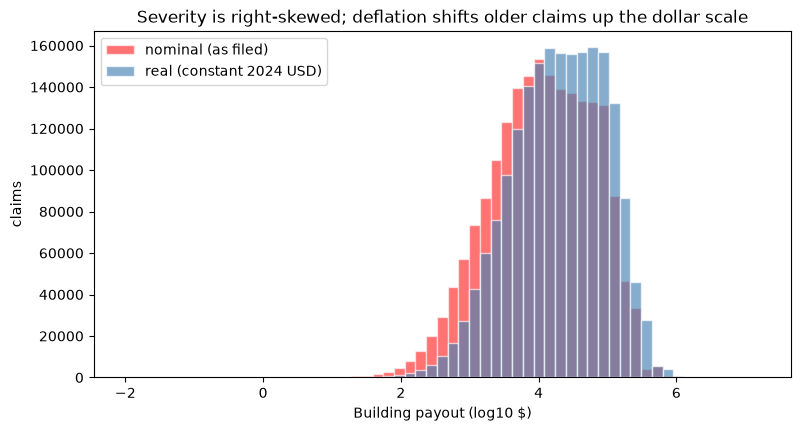

nominal: median $  12,047,   mean: $  36,412,   max: $10,741,477
real:    median $  21,229,   mean: $  53,008,   max: $16,065,116


In [311]:
# EDA
# payout distribution is right-skewed -> log-link
# Real (2024 USD) vs nominal on the SAME axes.
# deflation shifts the older, smaller-dollar claims up and tightens the left 
# tail. The skew survives in both
real = model_df["amountPaidOnBuildingClaim"]
nominal = model_df["amountPaidOnBuildingClaim_nominal"]

bins = np.linspace(
    np.log10(min(real.min(), nominal.min())),
    np.log10(max(real.max(), nominal.max())),
    60,
)
plt.hist(
    np.log10(nominal),
    bins=bins,
    color="red",
    alpha=0.55,
    edgecolor="white",
    label="nominal (as filed)",
)
plt.hist(
    np.log10(real),
    bins=bins,
    color="steelblue",
    alpha=0.65,
    edgecolor="white",
    label="real (constant 2024 USD)",
)
plt.xlabel("Building payout (log10 $)")
plt.ylabel("claims")
plt.title("Severity is right-skewed; deflation shifts older claims up the dollar scale")
plt.legend()
plt.show()

print(f"nominal: median ${nominal.median():>8,.0f},", end="   ")
print(f"mean: ${nominal.mean():>8,.0f},", end="   ")
print(f"max: ${nominal.max():>10,.0f}")

print(f"real:    median ${real.median():>8,.0f},", end="   ")
print(f"mean: ${real.mean():>8,.0f},", end="   ")
print(f"max: ${real.max():>10,.0f}")

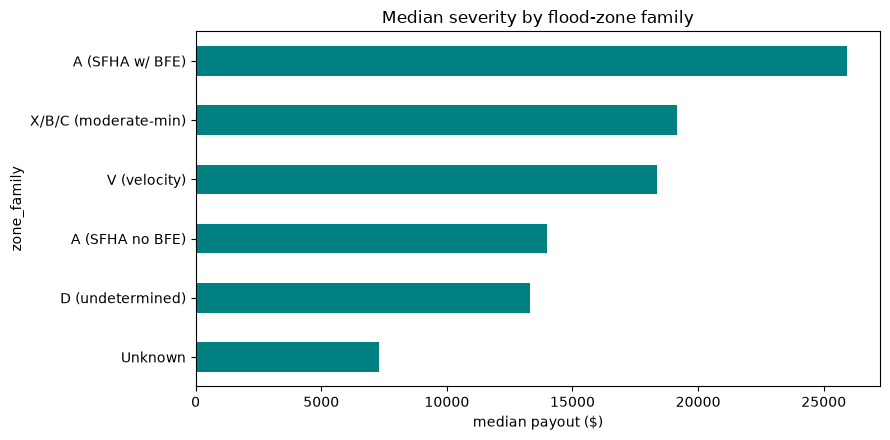

In [312]:
# median severity by flood-zone family
# the legacy zone scheme captures *some* signal (our baseline)
order = (
    model_df.groupby("zone_family")["amountPaidOnBuildingClaim"].median().sort_values()
)
order.plot(kind="barh", color="teal")
plt.xlabel("median payout ($)")
plt.title("Median severity by flood-zone family")
plt.tight_layout()
plt.show()

# Notes:
# put FEMA's zone codes (A01–A30, etc.) into six buckets:
# V (velocity) - any zone starting with V.
#   Coastal high-hazard areas exposed to wave action (most dangerous)
# A (SFHA w/ BFE)
#   zones starting with A that have a specific number (A01–A30, AE, etc.)
#   Special Flood Hazard Area with a Base Flood Elevation on record
# A (SFHA no BFE)
#   bare "A" zone.
#   Special Flood Hazard Area without an established Base Flood Elevation.
# X/B/C (moderate-min)
#   zones starting with X, B, or C.
#   Moderate-to-minimal risk, outside the 100-year floodplain.
# D (undetermined)
#   zone D. Risk exists but hasn't been assessed.
# Unknown
#   blank, missing, or anything that doesn't match the above.

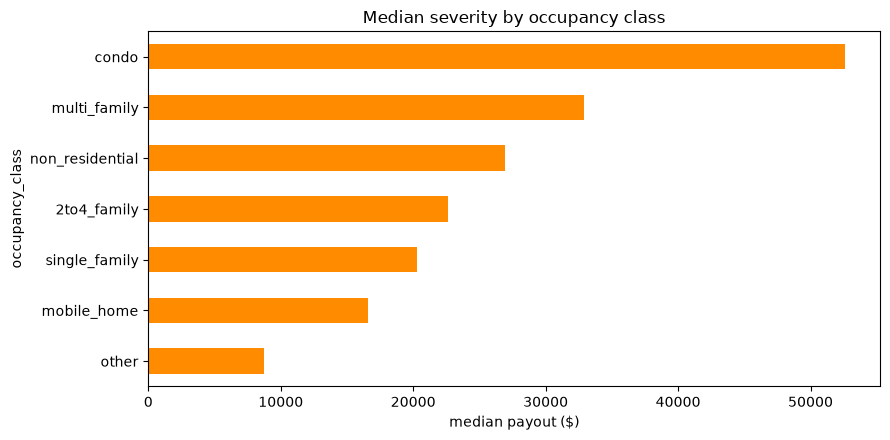

In [313]:
# occupancy class
model_df.groupby("occupancy_class")[
    "amountPaidOnBuildingClaim"
].median().sort_values().plot(kind="barh", color="darkorange")
plt.xlabel("median payout ($)")
plt.title("Median severity by occupancy class")
plt.tight_layout()
plt.show()

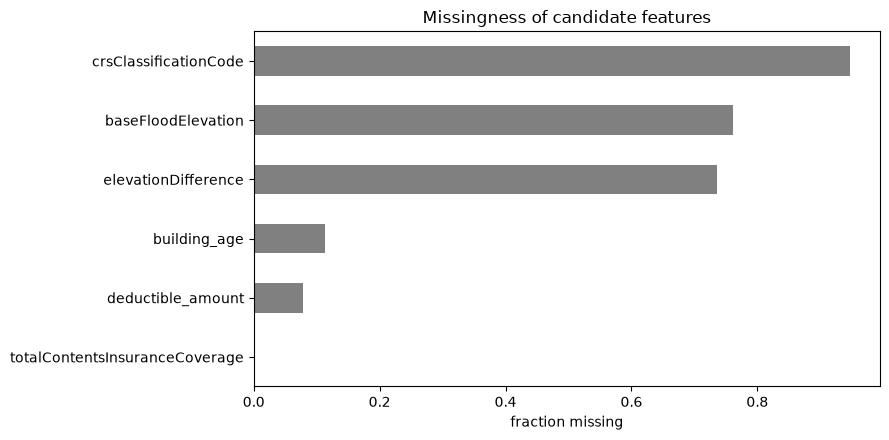

In [314]:
# how much is missing
# elevation fields mostly absent
miss = (
    model_df[
        [
            "elevationDifference",
            "baseFloodElevation",
            "building_age",
            "deductible_amount",
            "crsClassificationCode",
            "totalContentsInsuranceCoverage",
        ]
    ]
    .isna()
    .mean()
    .sort_values()
)
miss.plot(kind="barh", color="grey")
plt.xlabel("fraction missing")
plt.title("Missingness of candidate features")
plt.tight_layout()
plt.show()

## 7. Features and the leakage boundary

In [315]:
# leakage protection
# underwriting-time features only (present at underwriting)
# exclude everything post-flood to avoid leakage
NUMERIC = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "building_age",
    "crsClassificationCode",
    "elevationDifference",
]
CATEG = [
    "zone_family",
    "occupancy_class",
    "state",
    "floors_cat",
    "basement_cat",
    "postFIRMConstructionIndicator_i",
    "elevatedBuildingIndicator_i",
    "primaryResidenceIndicator_i",
]
TARGET = "amountPaidOnBuildingClaim"

X = model_df[NUMERIC + CATEG].copy()
y = model_df[TARGET].astype(float).values

# excluded post-flood fields (using these would be leakage)
LEAKY = [
    "waterDepth",
    "floodWaterDuration",
    "causeOfDamage",
    "buildingDamageAmount",
    "netBuildingPaymentAmount",
    "floodEvent",
    "amountPaidOnContentsClaim",
]
print("features used   :", len(NUMERIC), "numeric +", len(CATEG), "categorical")
print("excluded (leaky):", ", ".join(LEAKY))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")

features used   : 6 numeric + 8 categorical
excluded (leaky): waterDepth, floodWaterDuration, causeOfDamage, buildingDamageAmount, netBuildingPaymentAmount, floodEvent, amountPaidOnContentsClaim

train: (1603996, 14)   test: (400999, 14)


## 8. Preprocessing pipeline

In [316]:
# pipeline
#
# Monetary features get log1p BEFORE imputation/scaling
# With a log link raw-scaled heavy-tailed money lets the linear predictor
# extrapolate and exp() explode
# (reproduced in the 'post-mortem unstabilised GLM' section)
# When log()'d the GLM's effects become elasticities and predictions stay
# bounded
# > log1p handles zeros and passes NaN through to the imputer untouched.
from sklearn.preprocessing import FunctionTransformer

MONETARY_NUM = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
]
OTHER_NUM = [c for c in NUMERIC if c not in MONETARY_NUM]

cat_pipe = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        (
            "money",
            Pipeline(
                [
                    # feature_names_out needed so SHAP can recover column names
                    (
                        "log1p",
                        FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                    ),
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            MONETARY_NUM,
        ),
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            OTHER_NUM,
        ),
        ("cat", cat_pipe, CATEG),
    ]
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('money', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## 9. Models and a baseline to beat

| Model                                      | Family                          |
| ------------------------------------------ | ------------------------------- |
| **Baseline — global mean / median**        | trivial constants               |
| **Baseline — mean payout by flood zone**   | stylised zone-band proxy        |
| **GLM (Gamma, log-link)**                  | linear / GLM                    |
| **Random Forest (smeared log target)**     | tree ensemble — bagging         |
| **GBM (gradient boosting, gamma loss)**    | tree ensemble — boosting        |


A stacking ensemble was considered (Week 2's model over GLM + RF + GBM) but we ruled it out on our own evidence.  Stacking pays when base models make different mistakes, but here the families land within a few percent of each other out-of-time, the tuning surface is flat, and performance is data-limited. These are conditions under which a meta-learner has nothing to blend.

1. Baseline -> mean payout by flood zone "what does zone membership alone capture?" benchmark
2. Gamma GLM with log link
3. GBM -> HistGradientBoostingRegressor with gamma loss -> tree ensemble (boosting) 
4. Random Forest on log target 

Predictions are clipped at the policy's building coverage limit
- hard business rule (a payout above the cap is contractually impossible) -> not tuning trick

In [317]:
# helpers
from sklearn.metrics import d2_tweedie_score


def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5


def score_row(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE ($)": mean_absolute_error(y_true, y_pred),
        "RMSE ($)": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        # D2 = variance-explained on the GAMMA-DEVIANCE scale — the
        # like-for-like score for models that optimise deviance (both of ours
        # do). R2 is a squared-error score and can be destroyed by a handful
        # of huge errors that deviance barely notices (see post-mortem).
        "D2 (gamma)": d2_tweedie_score(y_true, y_pred, power=2),
    }


def clip_at_coverage(y_pred, X):
    """Cap predictions at the policy's building coverage limit.

    A payout above the limit is contractually impossible, so this is a
    business rule, not a tuning trick. Rows with no recorded limit are left
    unclipped.
    """
    cap = X["totalBuildingInsuranceCoverage"].to_numpy(dtype=float)
    cap = np.where(np.isfinite(cap) & (cap > 0), cap, np.inf)
    return np.minimum(y_pred, cap)


# two real models (the baseline is computed directly in the next cell)
# Gamma GLM
glm = Pipeline(
    [
        ("prep", preprocess),
        ("glm", TweedieRegressor(power=2, link="log", alpha=3, max_iter=5000)),
    ]
)
gbm = Pipeline(
    [
        ("prep", preprocess),
        (
            "gbm",
            HistGradientBoostingRegressor(
                loss="gamma",
                learning_rate=0.05,
                max_iter=400,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
print("models defined")

models defined


In [318]:
# trivial baselines: dumb numbers every model must beat
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor


class ZoneMeanRegressor(BaseEstimator, RegressorMixin):
    """A stylised proxy for legacy zone-band rating: mean training payout by
    zone family, falling back to the global training mean for zones unseen in
    a fold. Wrapping the incumbent-style benchmark as an estimator lets it run
    inside the same cross-validation as the real models."""

    def __init__(self, col="zone_family"):
        self.col = col

    def fit(self, X, y):
        s = pd.Series(np.asarray(y, dtype=float), index=pd.Index(X[self.col]))
        self.zone_mean_ = s.groupby(level=0).mean()
        self.global_mean_ = float(np.mean(y))
        return self

    def predict(self, X):
        return X[self.col].map(self.zone_mean_).fillna(self.global_mean_).to_numpy()


BASELINES = [
    ("Baseline (global mean)", DummyRegressor(strategy="mean")),
    ("Baseline (global median)", DummyRegressor(strategy="median")),
    ("Baseline (zone mean)", ZoneMeanRegressor()),
]
print("baselines defined:", ", ".join(n for n, _ in BASELINES))


baselines defined: Baseline (global mean), Baseline (global median), Baseline (zone mean)


## 10. Evaluation — random 80/20 split

In [319]:
# BE note:
# > local runtime on full data:     ~ 1m 12.9s
# > local runtime on sample data:   ~ 0m 02.3s
results = []

# Baseline
# mean payout by rated flood zone (legacy scheme), using TRAIN only (no leakage)
zone_mean = pd.Series(y_train, index=X_train["zone_family"]).groupby(level=0).mean()
baseline_pred = X_test["zone_family"].map(zone_mean).fillna(y_train.mean()).values
results.append(score_row("Baseline (zone mean)", y_test, baseline_pred))

# GLM
glm.fit(X_train, y_train)
results.append(
    score_row(
        "GLM (Gamma, log-link)", y_test, clip_at_coverage(glm.predict(X_test), X_test)
    )
)
# GBM
gbm.fit(X_train, y_train)
results.append(
    score_row("GBM (gamma loss)", y_test, clip_at_coverage(gbm.predict(X_test), X_test))
)

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(2).to_string())

                        MAE ($)  RMSE ($)    R2  D2 (gamma)
Model                                                      
Baseline (zone mean)   51290.17  98419.35  0.01        0.03
GLM (Gamma, log-link)  47893.58  96591.80  0.05        0.10
GBM (gamma loss)       36539.58  80967.54  0.33        0.36


In [320]:
# context-free baselines on the same random split
# (zone mean is already in the table above -> it is the incumbent-style proxy)
for name, est in BASELINES[:2]:
    est.fit(X_train, y_train)
    results.append(score_row(name, y_test, est.predict(X_test)))

MODEL_ORDER = [
    "Baseline (global mean)",
    "Baseline (global median)",
    "Baseline (zone mean)",
    "GLM (Gamma, log-link)",
    "GBM (gamma loss)",
]
results_df = (
    pd.DataFrame(results)
    .drop_duplicates("Model", keep="last")
    .set_index("Model")
    .reindex(MODEL_ORDER)
)
print(results_df.round(2).to_string())


                           MAE ($)   RMSE ($)    R2  D2 (gamma)
Model                                                          
Baseline (global mean)    52247.51   99045.90 -0.00       -0.00
Baseline (global median)  44964.74  103957.89 -0.10       -0.58
Baseline (zone mean)      51290.17   98419.35  0.01        0.03
GLM (Gamma, log-link)     47893.58   96591.80  0.05        0.10
GBM (gamma loss)          36539.58   80967.54  0.33        0.36


In [321]:
# BE note:
# > local runtime on full data:     ~ 4m 41.7s
# > local runtime on sample data:   ~ 0m 06.9s

# 5-fold cross-validated Mean Absolute Error
# > !not using test for tuning
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, est in [("GLM", glm), ("GBM", gbm)]:
    s = -cross_val_score(
        est, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error"
    )
    print(f"CV MAE  {name}:  ${s.mean():,.0f}  ± ${s.std():,.0f}")

CV MAE  GLM:  $48,787  ± $92
CV MAE  GBM:  $36,730  ± $88


In [322]:
# the identical 5-fold CV for the baselines - one frame, every model
for name, est in BASELINES:
    s = -cross_val_score(
        est, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error"
    )
    print(f"CV MAE  {name:26s}:  ${s.mean():,.0f}  \u00b1 ${s.std():,.0f}")


CV MAE  Baseline (global mean)    :  $52,469  ± $86
CV MAE  Baseline (global median)  :  $45,211  ± $133
CV MAE  Baseline (zone mean)      :  $51,504  ± $88


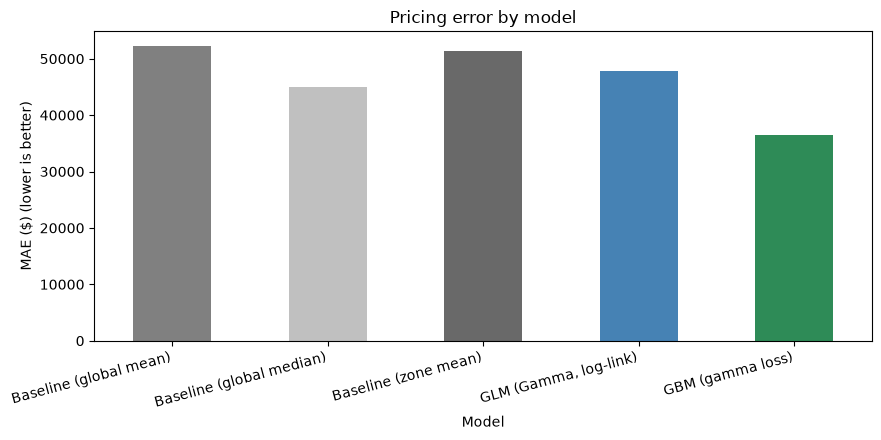

The GBM cuts average pricing error by 29% versus the legacy zone scheme.


,MAE ($),RMSE ($),R2,D2 (gamma)
Model,,,,
Baseline (global mean),52247.507398,99045.901159,-0.000007,-0.000012
Baseline (global median),44964.743979,103957.891060,-0.101653,-0.575438
Baseline (zone mean),51290.172956,98419.353752,0.012605,0.034611
"GLM (Gamma, log-link)",47893.579793,96591.802581,0.048934,0.095610
GBM (gamma loss),36539.583698,80967.538849,0.331730,0.362420


In [323]:
# MAE by model (lower is better)
# greys = baselines, blue = GLM, green = GBM (order fixed by MODEL_ORDER)
results_df["MAE ($)"].plot(
    kind="bar", color=["grey", "silver", "dimgrey", "steelblue", "seagreen"]
)
plt.ylabel("MAE ($) (lower is better)")
plt.title("Pricing error by model")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

b = results_df.loc["Baseline (zone mean)", "MAE ($)"]
g = results_df.loc["GBM (gamma loss)", "MAE ($)"]
print(
    f"The GBM cuts average pricing error by {(b-g)/b:.0%} versus the legacy zone scheme."
)

results_df

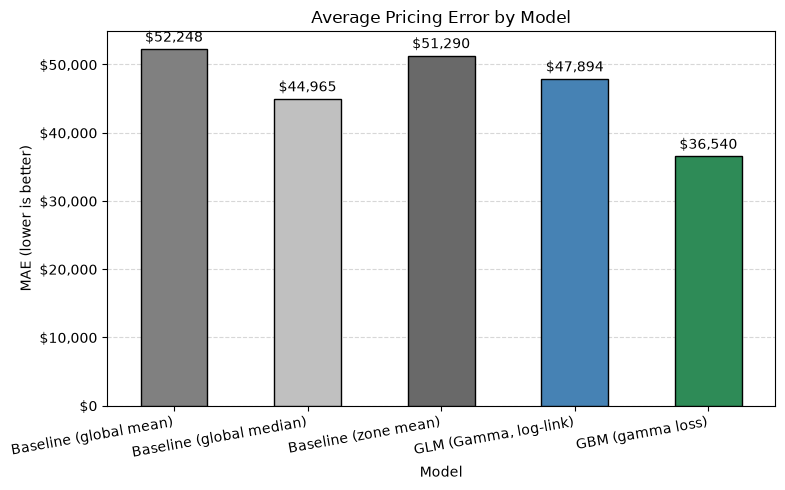


--- Model Impact ---
The GBM reduces average pricing error by 28.8% versus the legacy zone scheme
In absolute terms this is an improvement of $14,751 per claim on average


,MAE ($),RMSE ($),R2,D2 (gamma)
Model,,,,
Baseline (global mean),52247.507398,99045.901159,-0.000007,-0.000012
Baseline (global median),44964.743979,103957.891060,-0.101653,-0.575438
Baseline (zone mean),51290.172956,98419.353752,0.012605,0.034611
"GLM (Gamma, log-link)",47893.579793,96591.802581,0.048934,0.095610
GBM (gamma loss),36539.583698,80967.538849,0.331730,0.362420


In [324]:
import matplotlib.ticker as ticker

ax = results_df["MAE ($)"].plot(
    kind="bar",
    color=["grey", "silver", "dimgrey", "steelblue", "seagreen"],
    figsize=(8, 5), 
    edgecolor="black", 
    zorder=3, 
)

# top of bar labels
ax.bar_label(ax.containers[0], fmt="${:,.0f}", padding=3)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

plt.ylabel("MAE (lower is better)")
plt.title("Average Pricing Error by Model")
plt.xticks(rotation=10, ha="right")  
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

baseline_mae = results_df.loc["Baseline (zone mean)", "MAE ($)"]
gbm_mae = results_df.loc["GBM (gamma loss)", "MAE ($)"]

improvement_pct = (baseline_mae - gbm_mae) / baseline_mae
improvement_abs = baseline_mae - gbm_mae

print("\n--- Model Impact ---")
print(
    f"The GBM reduces average pricing error by {improvement_pct:.1%} versus the legacy zone scheme"
)
print(
    f"In absolute terms this is an improvement of ${improvement_abs:,.0f} per claim on average"
)
results_df

### Post-mortem - un-stabilised GLM

!

In [325]:
# post-mortem / validation
# Running the SAME Gamma GLM without the stabilisation
# (this was method used in the first draft)
# monetary features raw-scaled (no log1p) and predictions not clipped at the
# coverage limit
#
# Reproduced deliberately here as diagnosis is informative
# The mechanism:
#   1. a log-link GLM predicts exp(linear predictor)
#       raw heavy-tailed coverage is unbounded after scaling, so extreme rows
#       push the linear predictor past anything seen in training and exp()
#       turns that into an absurd prediction
#   2. R2 is a squared-error score
#       a few blown rows can make it explode while MAE (linear) barely moves
#   3. the GLM optimises gamma deviance, not squared error
#       > judged on D2 it is poor but not broken
#       > judged on R2 it can look catastrophic.
#       Metric choice is part of methodology, hence D2 on every scoreboard
naive_prep = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            # all numerics raw-scaled, money included
            NUMERIC,  
        ),
        ("cat", cat_pipe, CATEG),
    ]
)
naive_glm = Pipeline(
    [
        ("prep", naive_prep),
        ("glm", TweedieRegressor(power=2, link="log", alpha=3, max_iter=5000)),
    ]
).fit(X_train, y_train)
# deliberately unclipped
naive_pred = naive_glm.predict(X_test)  

pm = pd.DataFrame(
    [
        score_row("GLM naive (raw-$, unclipped)", y_test, naive_pred),
        results_df.loc["GLM (Gamma, log-link)"].rename("x").to_dict()
        | {"Model": "GLM stabilised (log1p + clip)"},
    ]
).set_index("Model")
print(pm.round(4).to_string(), end="\n\n")

print(f"largest single naive prediction: ${naive_pred.max():,.0f}")
print(f"largest actual payout in test  : ${y_test.max():,.0f}")

                                  MAE ($)      RMSE ($)        R2  D2 (gamma)
Model                                                                        
GLM naive (raw-$, unclipped)   52084.5678  1.458231e+06 -215.7618      0.0659
GLM stabilised (log1p + clip)  47893.5798  9.659180e+04    0.0489      0.0956

largest single naive prediction: $918,929,676
largest actual payout in test  : $13,412,765


## 11. Out-of-time validation (train pre-2020, test 2020 onwards)

In [326]:
# out-of-time split:
#   train on losses before CUTOFF_YEAR, test on the rest.
# From genAI:
# The random split answers "can we price claims from events we have already
# seen?" - Hurricane Harvey's claims sit in both train and test.
# The committee's actual question is whether a model trained on the past can
# price NEXT year's book, so here the test years sit strictly after the
# training years, and CV folds are grouped by year so no fold ever contains
# its own year.
#
# BE note: this now means that the split share is set by the cutoff, not chosen
#
# The future differing from the past (different events, states, coding
# regimes, real severity trend) is what this measures
# Whilst we could rebalance or statify across the cutoff it would leak the
# future back in
# Checks:
# > (a) the test share is big enough for stable metrics (printed below) and
# > (b) the finding is not an artefact of one particular window
#   (the cutoff sweep in the next cell)

# BE note:
# > local runtime on full data:     ~ 1m 7.9s
# > local runtime on sample data:   ~ 0m 2.6s

from sklearn.model_selection import GroupKFold

CUTOFF_YEAR = 2020
years = pd.to_numeric(model_df["yearOfLoss"], errors="coerce").to_numpy()

is_test = years >= CUTOFF_YEAR
X_train, X_test = X[~is_test], X[is_test]
y_train, y_test = y[~is_test], y[is_test]
print(
    f"train (< {CUTOFF_YEAR}): {len(X_train):,} rows   "
    f"test (>= {CUTOFF_YEAR}): {len(X_test):,} rows   "
    f"({is_test.mean():.0%} of claims)"
)
print("\nclaims per test year:")
print(pd.Series(years[is_test]).astype(int).value_counts().sort_index().to_string())

# year-grouped 5-fold CV on the training years
# precomputed as index pairs so every downstream 
# GridSearchCV / cross_val_score picks it up via cv= with no groups= plumbing
gkf = GroupKFold(n_splits=5)
cv = list(gkf.split(X_train, y_train, groups=years[~is_test]))

# zone baseline recomputed on this split (train only)
zone_mean = pd.Series(y_train, index=X_train["zone_family"]).groupby(level=0).mean()
baseline_pred = X_test["zone_family"].map(zone_mean).fillna(y_train.mean()).values

# refit the (untuned) models out-of-time
oot = [score_row("Baseline (zone mean)", y_test, baseline_pred)]
glm.fit(X_train, y_train)
oot.append(
    score_row(
        "GLM (Gamma, log-link)", y_test, clip_at_coverage(glm.predict(X_test), X_test)
    )
)
gbm.fit(X_train, y_train)
oot.append(
    score_row("GBM (gamma loss)", y_test, clip_at_coverage(gbm.predict(X_test), X_test))
)
oot_df = pd.DataFrame(oot).set_index("Model")
print("\n", oot_df.round(2).to_string())

# important: gap is the finding
# How much a naive random-split evaluation overstates deployable performance 
# (event memorisation + genuine drift)
gap = (oot_df["MAE ($)"] - results_df["MAE ($)"]).dropna()
print("\nMAE gap (out-of-time minus random split):")
print(gap.round(0).to_string())

train (< 2020): 1,791,249 rows   test (>= 2020): 213,746 rows   (11% of claims)

claims per test year:
2020    24010
2021    34723
2022    44694
2023    16267
2024    82695
2025    10397
2026      960

                         MAE ($)   RMSE ($)    R2  D2 (gamma)
Model                                                       
Baseline (zone mean)   65178.47  159465.57 -0.02       -0.09
GLM (Gamma, log-link)  64365.16  158406.63 -0.01       -0.05
GBM (gamma loss)       61041.92  153452.22  0.05       -0.09

MAE gap (out-of-time minus random split):
Model
Baseline (zone mean)     13888.0
GBM (gamma loss)         24502.0
GLM (Gamma, log-link)    16472.0


### Data maturity check: is the test set younger or just later?

In [327]:
# claim-maturity diagnostic: severity and volume by accident year
# (uses real, CPI-adjusted severities; run BEFORE trusting the OOT results)
sev = pd.DataFrame({"year": years, "y": y}).dropna()
by_year = (
    sev.groupby(sev["year"].astype(int))["y"]
    .agg(claims="size", median_sev="median", mean_sev="mean")
)
print("last 10 accident years:")
print(by_year.tail(10).round(0).to_string())

# crude immaturity flag: is the latest year's median far below the recent norm?
ref = by_year["median_sev"].iloc[-8:-2].median()  # reference: years -8..-3
last_yr, last_med = by_year.index[-1], by_year["median_sev"].iloc[-1]
ratio = last_med / ref
print(
    f"\nlatest year ({last_yr}) median severity = {ratio:.0%} of the "
    f"median of the six preceding years (${last_med:,.0f} vs ${ref:,.0f})"
)
if ratio < 0.75:
    print(
        "WARNING: the latest accident year looks materially cheaper than the\n"
        "recent norm - consistent with unsettled (immature) claims. Consider\n"
        "trimming it from the OOT test window or filtering to closed claims."
    )
else:
    print("no strong immaturity signal at the annual-median level")
print(
    "note: a flat median does not rule out immaturity in the tail\n"
    "(large claims settle slowest) - see the limitations section"
)


last 10 accident years:
      claims  median_sev  mean_sev
year                              
2017  110352     66555.0   96052.0
2018   33088     21289.0   49841.0
2019   28695     31913.0   52975.0
2020   24010     17002.0   39733.0
2021   34723     27344.0   54920.0
2022   44694     60190.0  112410.0
2023   16267     32671.0   55014.0
2024   82695     68000.0   93222.0
2025   10397     28090.0   51263.0
2026     960     16955.0   35798.0

latest year (2026) median severity = 53% of the median of the six preceding years ($16,955 vs $32,292)
recent norm - consistent with unsettled (immature) claims. Consider
trimming it from the OOT test window or filtering to closed claims.
note: a flat median does not rule out immaturity in the tail
(large claims settle slowest) - see the limitations section


### baselines and third model family

In [328]:
# two wrapper estimators, born of Reflections 4 and 5
from sklearn.base import BaseEstimator, RegressorMixin, clone


class CoverageClippedRegressor(BaseEstimator, RegressorMixin):
    """Applies the coverage-cap business rule INSIDE predict(), so the rule
    travels with the model into every evaluation protocol (holdout, CV, ...).
    Reflection 5: a post-hoc clip cannot follow a model into cross_val_score;
    a wrapper can."""

    def __init__(self, estimator, cap_col="totalBuildingInsuranceCoverage"):
        self.estimator = estimator
        self.cap_col = cap_col

    def fit(self, X, y):
        self.estimator_ = clone(self.estimator).fit(X, y)
        return self

    def predict(self, X):
        cap = X[self.cap_col].to_numpy(dtype=float)
        cap = np.where(np.isfinite(cap) & (cap > 0), cap, np.inf)
        return np.minimum(self.estimator_.predict(X), cap)


class SmearedLogTargetRegressor(BaseEstimator, RegressorMixin):
    """Fits the inner regressor on z = log1p(y) and back-transforms with
    Duan's smearing correction: E[y|x] ~= exp(f(x)) * mean(exp(resid)) - 1.
    Reflection 4: a naive expm1 back-transform is biased low (Jensen); the
    smearing factor is estimated from OUT-OF-BAG residuals where available,
    because in-bag RF residuals are optimistically small."""

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        z = np.log1p(np.asarray(y, dtype=float))
        self.estimator_ = clone(self.estimator).fit(X, z)
        oob = getattr(self.estimator_, "oob_prediction_", None)
        pred_z = oob if oob is not None else self.estimator_.predict(X)
        resid = z - pred_z
        resid = resid[np.isfinite(resid)]  # guard rare never-OOB rows
        self.smear_ = float(np.mean(np.exp(resid)))
        return self

    def predict(self, X):
        return np.maximum(
            np.exp(self.estimator_.predict(X)) * self.smear_ - 1.0, 0.0
        )


print("wrappers defined: CoverageClippedRegressor, SmearedLogTargetRegressor")


wrappers defined: CoverageClippedRegressor, SmearedLogTargetRegressor


In [329]:
# third model family: Random Forest (bagging) on a smeared log target
# BE note:
# > local runtime on full data:     ~ TBC (n_jobs=-1, max_samples=0.3 caps it)
# > local runtime on sample data:   ~ 0m 0.9s
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline(
    [
        ("prep", preprocess),
        (
            "rf",
            SmearedLogTargetRegressor(
                RandomForestRegressor(
                    n_estimators=200,
                    min_samples_leaf=20,
                    max_samples=0.3,
                    oob_score=True,  # needed for the OOB smearing factor
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                )
            ),
        ),
    ]
)

# extended out-of-time table: EVERY model clipped at coverage (Reflection 5),
# which also re-scores the zone baseline clipped, superseding the unclipped
# row from the original 3-model table via drop_duplicates(keep="last")
oot_ext = list(oot)
for name, est in BASELINES:
    est.fit(X_train, y_train)
    oot_ext.append(
        score_row(name, y_test, clip_at_coverage(est.predict(X_test), X_test))
    )

rf.fit(X_train, y_train)
print(
    "Duan smearing factor (OOB):",
    round(rf.named_steps["rf"].smear_, 3),
    "(> 1 means the naive expm1 back-transform was biased low)",
)
oot_ext.append(
    score_row(
        "RF (bagging, smeared log target)",
        y_test,
        clip_at_coverage(rf.predict(X_test), X_test),
    )
)

OOT_ORDER = [
    "Baseline (global mean)",
    "Baseline (global median)",
    "Baseline (zone mean)",
    "GLM (Gamma, log-link)",
    "RF (bagging, smeared log target)",
    "GBM (gamma loss)",
]
oot_ext_df = (
    pd.DataFrame(oot_ext)
    .drop_duplicates("Model", keep="last")
    .set_index("Model")
    .reindex(OOT_ORDER)
)
print("\n", oot_ext_df.round(2).to_string())

# lift vs the incumbent-style proxy AND vs the best trivial baseline -
# but per Reflection 7, MAE lift is a COMMUNICATION number, not the
# model-selection criterion (that is gamma deviance, next cells)
inc = oot_ext_df.loc["Baseline (zone mean)", "MAE ($)"]
best_base = oot_ext_df.loc[OOT_ORDER[:3], "MAE ($)"].min()
print(f"\nzone-proxy MAE: ${inc:,.0f}   best trivial baseline MAE: ${best_base:,.0f}")
for m in OOT_ORDER[3:]:
    mae = oot_ext_df.loc[m, "MAE ($)"]
    print(
        f"  {m}: {1 - mae / inc:+.1%} vs zone proxy, "
        f"{1 - mae / best_base:+.1%} vs best baseline"
    )
print(
    "(if the global median leads the baselines on MAE -> median trap\n"
    "-> check Gini and D2 before drawing conclusions)"
)

Duan smearing factor (OOB): 1.886 (> 1 means the naive expm1 back-transform was biased low)

                                    MAE ($)   RMSE ($)    R2  D2 (gamma)
Model                                                                  
Baseline (global mean)            64726.98  160260.00 -0.04       -0.15
Baseline (global median)          68092.85  168572.53 -0.15       -1.87
Baseline (zone mean)              64464.97  159360.42 -0.02       -0.09
GLM (Gamma, log-link)             64365.16  158406.63 -0.01       -0.05
RF (bagging, smeared log target)  62323.07  157776.46 -0.00       -0.47
GBM (gamma loss)                  61041.92  153452.22  0.05       -0.09

zone-proxy MAE: $64,465   best trivial baseline MAE: $64,465
  GLM (Gamma, log-link): +0.2% vs zone proxy, +0.2% vs best baseline
  RF (bagging, smeared log target): +3.3% vs zone proxy, +3.3% vs best baseline
  GBM (gamma loss): +5.3% vs zone proxy, +5.3% vs best baseline
(if the global median leads the baselines on MAE -> med

In [330]:
# year-grouped 5-fold CV, every model in the identical, coverage-clipped frame
cv_rows = []
for name, est in BASELINES + [
    ("GLM (Gamma, log-link)", glm),
    ("RF (bagging, smeared log target)", rf),
    ("GBM (gamma loss)", gbm),
]:
    s = -cross_val_score(
        CoverageClippedRegressor(est),
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
    )
    cv_rows.append(
        {"Model": name, "CV MAE ($)": s.mean(), "CV MAE std ($)": s.std()}
    )
cv_all_df = pd.DataFrame(cv_rows).set_index("Model")
print(cv_all_df.round(0).to_string())


                                  CV MAE ($)  CV MAE std ($)
Model                                                       
Baseline (global mean)               48248.0          7482.0
Baseline (global median)             42673.0         13541.0
Baseline (zone mean)                 47882.0          7428.0
GLM (Gamma, log-link)                46364.0          8449.0
RF (bagging, smeared log target)     39716.0         12650.0
GBM (gamma loss)                     40201.0         11789.0


### Leakage audit

In [331]:
# leakage audit - machine-checked assertions (fail loudly, not silently)
feat = set(NUMERIC + CATEG)

# 1. no post-flood field, and no target, in the feature set
assert not feat & set(LEAKY), f"post-flood field in features: {feat & set(LEAKY)}"
assert TARGET not in feat, "target used as a feature"

# 2. preprocessing lives inside each model pipeline (fit on train folds only)
for name, est in [("GLM", glm), ("GBM", gbm), ("RF", rf)]:
    assert est.steps[0][0] == "prep", f"{name}: preprocessing outside the pipeline"

# 3. out-of-time split is strict
tr_years, te_years = years[~is_test], years[is_test]
assert (
    np.nanmax(tr_years) < CUTOFF_YEAR <= np.nanmin(te_years)
), "OOT split contaminated"

# 4. year-grouped CV: no fold validates on a year it trained on
for k, (tr_idx, va_idx) in enumerate(cv):
    overlap = set(tr_years[tr_idx]) & set(tr_years[va_idx])
    overlap = {v for v in overlap if v == v}  # drop NaN (NaN != NaN)
    assert not overlap, f"fold {k}: year(s) {overlap} straddle train/validation"

# Reflection 6b: surface what the year checks CANNOT see
n_nan_years = int(np.isnan(years).sum())
print(
    f"rows with missing yearOfLoss: {n_nan_years:,} "
    "(these fall on the training side by construction and sit outside the "
    "year assertions above)"
)
print("leakage audit passed: features, pipelines, OOT split, year-grouped folds")

rows with missing yearOfLoss: 0 (these fall on the training side by construction and sit outside the year assertions above)
leakage audit passed: features, pipelines, OOT split, year-grouped folds


In [332]:
# robustness of the gap to the choice of window
# repeats the out-of-time evaluation at several cutoffs (GBM + baseline only)
#
# If the lift over the baseline holds across windows, the finding is not an
# artefact of which events happen to sit in one particular test set
#
# BE note: one GBM fit per cutoff
# > local runtime on full data:     ~ 3m 1.0s
# > local runtime on sample data:   ~ 0m 5.3s

from sklearn.base import clone

sweep = []
for cut in [2016, 2018, 2020]:
    te = years >= cut
    m = clone(gbm).fit(X[~te], y[~te])
    pred = clip_at_coverage(m.predict(X[te]), X[te])
    zm = pd.Series(y[~te], index=X[~te]["zone_family"]).groupby(level=0).mean()
    base = X[te]["zone_family"].map(zm).fillna(y[~te].mean()).values
    sweep.append(
        {
            "cutoff": cut,
            "test share": f"{te.mean():.0%}",
            "baseline MAE ($)": mean_absolute_error(y[te], base),
            "GBM MAE ($)": mean_absolute_error(y[te], pred),
        }
    )
sweep_df = pd.DataFrame(sweep).set_index("cutoff")
sweep_df["GBM lift vs baseline"] = (
    1 - sweep_df["GBM MAE ($)"] / sweep_df["baseline MAE ($)"]
)
print(sweep_df.round(2).to_string())

       test share  baseline MAE ($)  GBM MAE ($)  GBM lift vs baseline
cutoff                                                                
2016          23%          62387.86     58673.99                  0.06
2018          14%          61031.83     55700.38                  0.09
2020          11%          65178.47     61041.92                  0.06


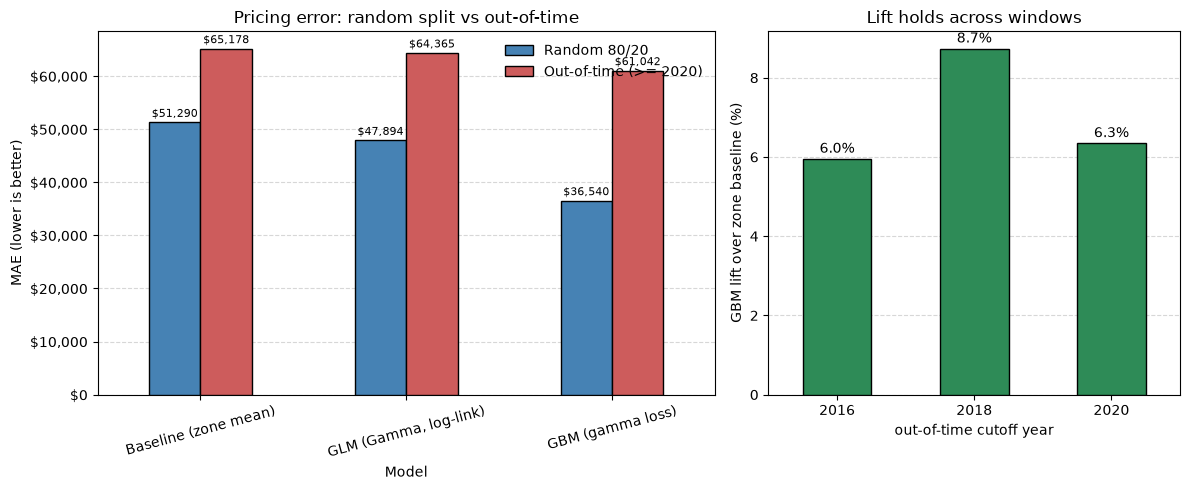

GBM lift over the zone baseline: 29% on the random split, 6% out-of-time.
The difference is the optimism of a naive evaluation
-> out-of-time number is the one to price on


In [333]:
# Left: MAE per model, random split vs out-of-time 
#   — gap between the two bars is the optimism of a naive evaluation
# Right: the GBM's lift over the zone baseline at each cutoff 
#   — if the bars are similar, the finding is not artefact of one particular 
#       test window
# the gap, drawn: random-split vs out-of-time MAE, and lift robustness
import matplotlib.ticker as ticker

comp = pd.DataFrame(
    {
        "Random 80/20": results_df["MAE ($)"],
        f"Out-of-time (>= {CUTOFF_YEAR})": oot_df["MAE ($)"],
    }
).loc[oot_df.index]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [3, 2]}
)

comp.plot(
    kind="bar", ax=ax1, color=["steelblue", "indianred"], edgecolor="black", zorder=3
)
for cont in ax1.containers:
    ax1.bar_label(cont, fmt="${:,.0f}", padding=2, fontsize=8)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax1.set_ylabel("MAE (lower is better)")
ax1.set_title("Pricing error: random split vs out-of-time")
ax1.tick_params(axis="x", rotation=15)
ax1.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax1.legend(frameon=False)

(sweep_df["GBM lift vs baseline"] * 100).plot(
    kind="bar", ax=ax2, color="seagreen", edgecolor="black", zorder=3
)
ax2.bar_label(ax2.containers[0], fmt="{:.1f}%", padding=2)
ax2.set_ylabel("GBM lift over zone baseline (%)")
ax2.set_xlabel("out-of-time cutoff year")
ax2.set_title("Lift holds across windows")
ax2.tick_params(axis="x", rotation=0)
ax2.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

plt.tight_layout()
plt.show()

lift_random = 1 - (
    results_df.loc["GBM (gamma loss)", "MAE ($)"]
    / results_df.loc["Baseline (zone mean)", "MAE ($)"]
)
lift_oot = 1 - (
    oot_df.loc["GBM (gamma loss)", "MAE ($)"]
    / oot_df.loc["Baseline (zone mean)", "MAE ($)"]
)
print(
    f"GBM lift over the zone baseline: {lift_random:.0%} on the random split, "
    f"{lift_oot:.0%} out-of-time."
)
print("The difference is the optimism of a naive evaluation")
print("-> out-of-time number is the one to price on")

### insurance grade evaluation -> want discrimination

In [334]:
# insurance-grade evaluation: gamma deviance, Gini (Lorenz), MAE for all models
# (every prediction set is coverage-clipped)
from sklearn.metrics import mean_gamma_deviance

_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz  # numpy 2.x rename


def gini_score(y_true, y_pred):
    """Ordering-based Gini: 2x the area between the Lorenz curve (claims
    sorted by predicted severity) and the diagonal. Actuals are averaged
    within tied prediction groups so the score is order-invariant
    (the zone baseline has only ~6 distinct predictions)."""
    df = pd.DataFrame(
        {"y": np.asarray(y_true, dtype=float), "p": np.asarray(y_pred, dtype=float)}
    )
    df["y_tie"] = df.groupby("p")["y"].transform("mean")
    y_sorted = df.sort_values("p", kind="mergesort")["y_tie"].to_numpy()
    cum = np.cumsum(y_sorted) / y_sorted.sum()
    x = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    return 1 - 2 * _trapz(cum, x)


preds_oot = {
    "Baseline (global median)": clip_at_coverage(
        np.full(len(y_test), float(np.median(y_train))), X_test
    ),
    "Baseline (zone mean)": clip_at_coverage(baseline_pred, X_test),
    "GLM (Gamma, log-link)": clip_at_coverage(glm.predict(X_test), X_test),
    "RF (bagging, smeared log target)": clip_at_coverage(rf.predict(X_test), X_test),
    "GBM (gamma loss)": clip_at_coverage(gbm.predict(X_test), X_test),
}

# gamma deviance needs strictly positive predictions; floor at the 1st
# percentile of TRAINING severity (a stated choice), not an arbitrary $1
DEV_FLOOR = float(np.percentile(y_train, 1))
print(f"gamma-deviance prediction floor: ${DEV_FLOOR:,.0f} (1st pct of train)")

ins_rows = []
for name, p in preds_oot.items():
    p_pos = np.maximum(p, DEV_FLOOR)
    ins_rows.append(
        {
            "Model": name,
            "Gamma deviance": mean_gamma_deviance(y_test, p_pos),
            "Gini": gini_score(y_test, p),
            "MAE ($)": mean_absolute_error(y_test, p),
        }
    )
ins_df = pd.DataFrame(ins_rows).set_index("Model")
print(ins_df.round(3).to_string())
print(
    "\nBE note for presentation: gamma deviance selects the model, Gini and the\n"
    "calibration plot below gate deployment, MAE translates to dollars"
)

gamma-deviance prediction floor: $395 (1st pct of train)
                                  Gamma deviance   Gini    MAE ($)
Model                                                             
Baseline (global median)                   5.081  0.005  68092.852
Baseline (zone mean)                       1.937  0.092  64464.968
GLM (Gamma, log-link)                      1.863  0.229  64365.164
RF (bagging, smeared log target)           2.602  0.299  62323.065
GBM (gamma loss)                           1.925  0.330  61041.919

BE note for presentation: gamma deviance selects the model, Gini and the
calibration plot below gate deployment, MAE translates to dollars


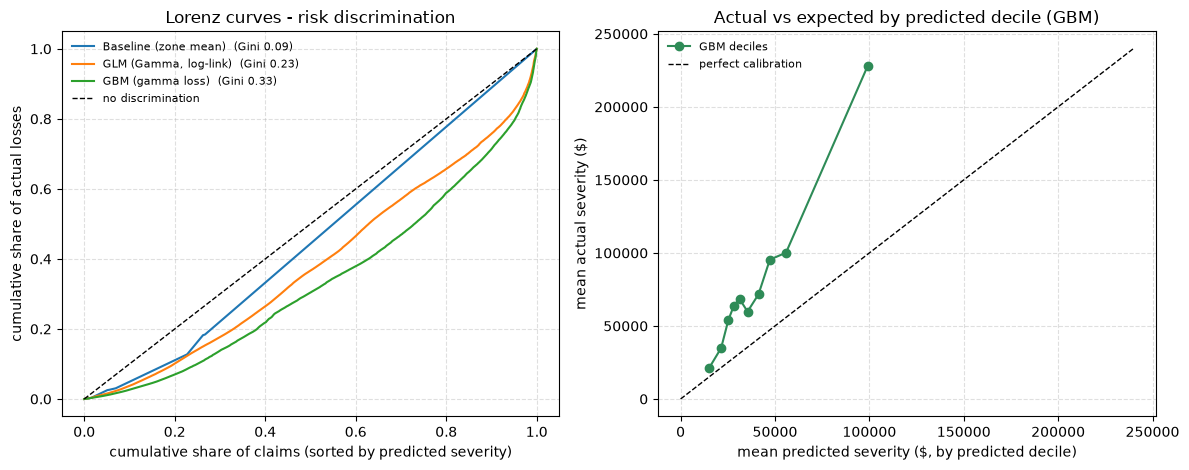

In [335]:
# Lorenz curves (discrimination) + actual-vs-expected calibration by decile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# Create a temporary DataFrame to group by predictions and average the actuals
temp_df = pd.DataFrame({'p': p, 'y': y_test})
# Average the actuals for any tied predictions
temp_df['y_averaged'] = temp_df.groupby('p')['y'].transform('mean')

for name in ["Baseline (zone mean)", "GLM (Gamma, log-link)", "GBM (gamma loss)"]:
    p = preds_oot[name]
    # Create a temporary DataFrame to group by predictions and average the actuals
    temp_df = pd.DataFrame({'p': p, 'y': y_test})
    # Average the actuals for any tied predictions
    temp_df['y_averaged'] = temp_df.groupby('p')['y'].transform('mean')
    # sort by prediction and use the averaged actuals
    order = np.argsort(temp_df['p'])
    y_sorted = np.asarray(temp_df['y_averaged'], dtype=float)[order]

    cum = np.insert(np.cumsum(y_sorted) / y_sorted.sum(), 0, 0.0)
    x = np.linspace(0, 1, len(cum))
    ax1.plot(x, cum, label=f"{name}  (Gini {gini_score(y_test, p):.2f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="no discrimination")
ax1.set_xlabel("cumulative share of claims (sorted by predicted severity)")
ax1.set_ylabel("cumulative share of actual losses")
ax1.set_title("Lorenz curves - risk discrimination")
ax1.legend(fontsize=8, frameon=False)
ax1.grid(linestyle="--", alpha=0.4)

p = preds_oot["GBM (gamma loss)"]
dec = pd.qcut(p, 10, labels=False, duplicates="drop")
cal = (
    pd.DataFrame({"pred": p, "actual": np.asarray(y_test, dtype=float)})
    .groupby(dec)
    .mean()
)
ax2.plot(cal["pred"], cal["actual"], "o-", color="seagreen", label="GBM deciles")
lim = [0, float(cal.to_numpy().max()) * 1.05]
ax2.plot(lim, lim, "k--", lw=1, label="perfect calibration")
ax2.set_xlabel("mean predicted severity ($, by predicted decile)")
ax2.set_ylabel("mean actual severity ($)")
ax2.set_title("Actual vs expected by predicted decile (GBM)")
ax2.legend(fontsize=8, frameon=False)
ax2.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

                                 MAE increase when shuffled ($)  MAE std  deviance increase when shuffled  rank (MAE)  rank (deviance)
totalBuildingInsuranceCoverage                         2340.559   56.052                            0.643           1                1
deductible_amount                                      1614.166   32.498                            0.148           2                2
occupancy_class                                         515.931   17.036                            0.097           6                3
building_age                                           1089.159   17.895                            0.096           3                4
basement_cat                                            523.414   11.304                            0.050           5                5
primaryResidenceIndicator_i                             181.712    4.644                            0.032          10                6
floors_cat                                             

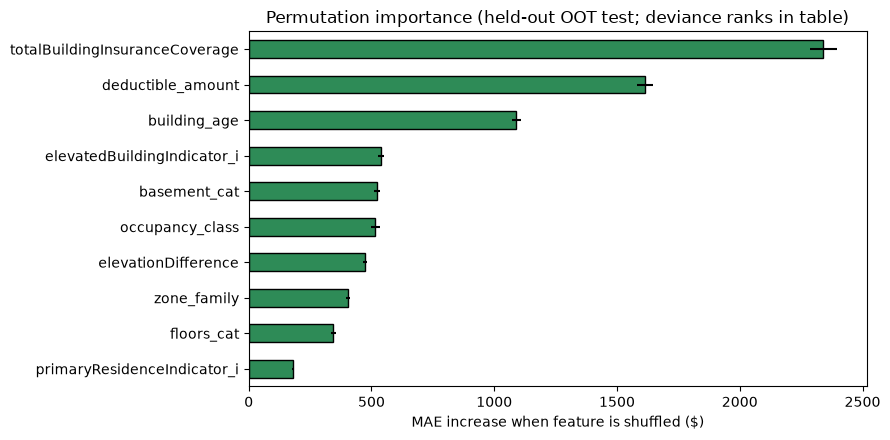

In [336]:
# permutation importance - held-out OOT test set, raw feature space,
# dual-scored per Reflection 7: gamma deviance selects, MAE communicates.
# Pipeline-level so each RAW column is permuted (one readable row per feature).
# Computed on TEST deliberately: importance that does not survive out-of-time
# is event memorisation, not transferable signal. (Unclipped model: the cap is
# a post-rule; here we measure the model's own reliance on each feature.)
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_gamma_deviance


def _gamma_dev_floored(y_true, y_pred):
    return mean_gamma_deviance(y_true, np.maximum(y_pred, DEV_FLOOR))


SCORERS = {
    "gamma_dev": make_scorer(_gamma_dev_floored, greater_is_better=False),
    "MAE": "neg_mean_absolute_error",
}

SUB = min(50_000, len(X_test))
rng = np.random.default_rng(RANDOM_STATE)
sub_idx = rng.choice(len(X_test), size=SUB, replace=False)
X_pi, y_pi = X_test.iloc[sub_idx], np.asarray(y_test, float)[sub_idx]

pi = permutation_importance(
    best_model,
    X_pi,
    y_pi,
    scoring=SCORERS,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
pi_df = pd.DataFrame(
    {
        "MAE increase when shuffled ($)": pi["MAE"].importances_mean,
        "MAE std": pi["MAE"].importances_std,
        "deviance increase when shuffled": pi["gamma_dev"].importances_mean,
    },
    index=X_pi.columns,
)
pi_df["rank (MAE)"] = (
    pi_df["MAE increase when shuffled ($)"].rank(ascending=False).astype(int)
)
pi_df["rank (deviance)"] = (
    pi_df["deviance increase when shuffled"].rank(ascending=False).astype(int)
)
pi_df = pi_df.sort_values("deviance increase when shuffled", ascending=False)
print(pi_df.round(3).to_string())

top = pi_df.sort_values("MAE increase when shuffled ($)", ascending=False).head(10)
top["MAE increase when shuffled ($)"].plot(
    kind="barh",
    xerr=top["MAE std"],
    color="seagreen",
    edgecolor="black",
)
plt.gca().invert_yaxis()
plt.xlabel("MAE increase when feature is shuffled ($)")
plt.title("Permutation importance (held-out OOT test; deviance ranks in table)")
plt.tight_layout()
plt.show()

## 12. Tuning

In [337]:
# tuning the models — cross-validated, cached, with the full search record
# > scored on gamma deviance, searched with successive halving (from Week 2)
# > The earlier MAE-scored randomised search is archived in cache
# BE note:
# > local runtime on full data:     ~ 158m 23s to 175m 34s
# > local runtime on sample data:   ~ 4m 54.2s (cache load is ~1.4s)
# The search is the expensive step, so its outcome is persisted and reruns
# just load it and fit each model once. Cache is keyed by dataset mode
# ("_oot": tuned on the out-of-time training set with year-grouped CV).


# tuning the models — cross-validated, cached, with the full search record
# R8 FIX: scored on gamma deviance (the selection metric per Reflection 7),
# searched with successive halving (Week 2's "strong default"; boosting
# iterations are the halving resource). The earlier MAE-scored randomised
# search is ARCHIVED in the cache and its CSVs kept: it is the R8 evidence.
# BE note:
# > full data, previous MAE-scored randomised search: ~158m 23s to 175m 34s
# > full data, this halving+grid search:              ~ TBC (est. 60–120m)
# > sample data:                                      ~ TBC (est. 3–5m; cache load ~1.4s)
# The search is the expensive step, so its outcome is persisted and reruns
# just load it. Cache is keyed by dataset mode ("_oot"). A cached record
# tuned on the wrong scorer is treated as stale and superseded AUTOMATICALLY,
# so FORCE_RETUNE stays False; set it True only to redo a like-for-like search.
from sklearn.base import clone
import sklearn

try:  # halving is experimental in some sklearn versions, stable in others
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
except ImportError:
    pass
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import make_scorer, mean_gamma_deviance


def _gamma_dev_floored(y_true, y_pred):
    return mean_gamma_deviance(y_true, np.maximum(y_pred, DEV_FLOOR))


GAMMA_SCORER = make_scorer(_gamma_dev_floored, greater_is_better=False)
SCORING_NAME = "neg_mean_gamma_deviance (floored at 1st pct of train severity)"

TUNED_PARAMS = Path("models/tuned_params.json")
FORCE_RETUNE = False
mode_key = ("sample" if USE_SAMPLE else "full") + "_oot"

cache = json.loads(TUNED_PARAMS.read_text()) if TUNED_PARAMS.exists() else {}
entry = {} if FORCE_RETUNE else cache.get(mode_key, {})

# R8 auto-invalidation: archive the MAE-scored record (evidence), retune
if entry and entry.get("scoring") != SCORING_NAME:
    print(
        f"cache [{mode_key}] was tuned with scoring={entry.get('scoring')!r} "
        f"— superseded; retuning on {SCORING_NAME!r}"
    )
    cache[f"{mode_key}_superseded_mae"] = entry
    entry = {}


def _best_params(entry, name):
    """Read the reload params from either the new record shape or the old flat one."""
    node = entry[name]
    return (
        node["best_params"]
        if isinstance(node, dict) and "best_params" in node
        else node
    )


if entry:
    print(f"loaded cached tuning record [{mode_key}] from {TUNED_PARAMS}")
    print(
        f"  tuned {entry.get('tuned_at', 'unknown')}  "
        f"on {entry.get('n_train', 0):,} rows  "
        f"(cutoff {entry.get('cutoff_year', '?')}, "
        f"sklearn {entry.get('sklearn', '?')})"
    )
    for name in ["glm", "gbm"]:
        node = entry[name]
        if isinstance(node, dict):
            score = node.get("best_cv_score", node.get("best_cv_mae"))
            print(
                f"  {name.upper()} best CV score: {score:,.4g}   "
                f"params: {node.get('best_params')}"
            )

    # staleness check: the cache can't be trusted if the training data changed
    if entry.get("n_train") not in (None, len(X_train)) or entry.get(
        "cutoff_year"
    ) not in (None, CUTOFF_YEAR):
        print(
            "  WARNING: cached record was tuned on different data "
            f"({entry.get('n_train', '?'):,} rows, cutoff {entry.get('cutoff_year', '?')}; "
            f"current: {len(X_train):,} rows, cutoff {CUTOFF_YEAR}) — "
            "set FORCE_RETUNE = True to refresh."
        )

    glm_best = clone(glm).set_params(**_best_params(entry, "glm")).fit(X_train, y_train)
    gbm_best = clone(gbm).set_params(**_best_params(entry, "gbm")).fit(X_train, y_train)
else:
    # GLM: same alpha grid, now deviance-scored
    glm_search = GridSearchCV(
        glm,
        {"glm__alpha": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]},
        scoring=GAMMA_SCORER,
        cv=cv,
    )
    glm_search.fit(X_train, y_train)
    print("GLM best alpha:", glm_search.best_params_["glm__alpha"])

    # GBM: successive halving; max_iter is the RESOURCE, so it leaves the grid.
    # clone() is essential — set_params on gbm directly would mutate the
    # global pipeline used by every later cell.
    gbm_search = HalvingRandomSearchCV(
        clone(gbm).set_params(gbm__early_stopping=False),
        {
            "gbm__learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
            "gbm__max_leaf_nodes": [31, 63, 127, 255],
            "gbm__l2_regularization": [0.0, 0.1, 1.0, 10.0],
            "gbm__min_samples_leaf": [5, 10, 20, 50, 100],
        },
        n_candidates=25,  # default 'exhaust' would pick its own count
        resource="gbm__max_iter",
        min_resources=45,
        max_resources=1215,  # 45 -> 135 -> 405 -> 1215 only if candidates remain
        factor=3,
        scoring=GAMMA_SCORER,
        cv=cv,
        random_state=RANDOM_STATE,
    )
    gbm_search.fit(X_train, y_train)

    # guarantee the reload path gets the full searched configuration
    gbm_params = dict(gbm_search.best_params_)
    gbm_params.setdefault("gbm__max_iter", int(gbm_search.n_resources_[-1]))
    gbm_params["gbm__early_stopping"] = False
    print(
        "GBM best params:",
        {k.replace("gbm__", ""): v for k, v in gbm_params.items()},
    )

    glm_best = glm_search.best_estimator_
    gbm_best = gbm_search.best_estimator_

    # full search record -> one CSV per model: every candidate with its
    # params, mean/std CV score, per-fold scores, and fit times. NEW
    # filenames: the old MAE-scored CSVs are R8 evidence, do not overwrite.
    for name, search in [("glm", glm_search), ("gbm", gbm_search)]:
        out = Path(f"models/cv_results_{mode_key}_{name}_gammadev.csv")
        out.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(search.cv_results_).to_csv(out, index=False)
        print(f"saved full CV results -> {out}")

    def record(search, step, best_params):
        """Tuning record for one model: reload params + provenance + audit trail."""
        fitted = search.best_estimator_.named_steps[step]
        return {
            "best_params": best_params,  # the reload configuration
            "best_cv_score": float(-search.best_score_),  # gamma deviance now
            "n_candidate_rows": len(search.cv_results_["params"]),
            # EVERY hyperparameter of the fitted regressor, searched or not —
            # if the notebook's model definition later drifts, this shows what
            # the cached params were actually tuned against
            "full_estimator_params": {
                k: v
                for k, v in fitted.get_params().items()
                if isinstance(v, (int, float, str, bool, type(None)))
            },
        }

    cache[mode_key] = {
        "tuned_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "n_train": int(len(X_train)),
        "cutoff_year": int(CUTOFF_YEAR),
        "scoring": SCORING_NAME,
        "search": "GLM: grid; GBM: successive halving (resource=max_iter)",
        "cv": "5-fold year-grouped (no fold contains its own year)",
        "sklearn": sklearn.__version__,
        "glm": record(glm_search, "glm", glm_search.best_params_),
        "gbm": record(gbm_search, "gbm", gbm_params),
    }
    TUNED_PARAMS.parent.mkdir(parents=True, exist_ok=True)
    TUNED_PARAMS.write_text(json.dumps(cache, indent=2))
    print(f"saved tuning record [{mode_key}] -> {TUNED_PARAMS}")

# refresh the scoreboard with the tuned models (test metrics stay out of the
# cache file: the tuning record is CV-only, the scoreboard is reporting)
tuned = [
    score_row("Baseline (zone mean)", y_test, baseline_pred),
    score_row(
        "GLM (tuned)", y_test, clip_at_coverage(glm_best.predict(X_test), X_test)
    ),
    score_row(
        "GBM (tuned)", y_test, clip_at_coverage(gbm_best.predict(X_test), X_test)
    ),
]
tuned_df = pd.DataFrame(tuned).set_index("Model")
print("\n", tuned_df.round(3).to_string())

# HEADLINE MODEL DECISION — revisit after the deviance-scored search runs.
# History: the earlier MAE-scored searches picked unstable winners on a flat
# surface and transferred no out-of-time gain (-$4, then +$654 MAE vs
# defaults) with WORSE gamma deviance — that is Reflection 8, and those
# searches are archived (cache key *_superseded_mae; models/cv_results_*.csv;
# 26-07-04 notebook outputs in git history).
# MORNING CHECK for the deviance-scored winner in tuned_df above:
#   - if GBM (tuned) does NOT clearly beat the untuned GBM on gamma deviance
#     out-of-time, keep best_model = gbm ("re-tuned on the correct criterion
#     and confirmed the ceiling") — expected outcome;
#   - if it clearly wins on deviance, switch best_model = gbm_best and
#     re-run the cells below it.
best_model = gbm  # untuned pipeline, fitted on the out-of-time training set

cache [full_oot] was tuned with scoring='neg_mean_absolute_error' — superseded; retuning on 'neg_mean_gamma_deviance (floored at 1st pct of train severity)'
GLM best alpha: 0.1
GBM best params: {'min_samples_leaf': 10, 'max_leaf_nodes': 63, 'learning_rate': 0.03, 'l2_regularization': 1.0, 'max_iter': 405, 'early_stopping': False}
saved full CV results -> models/cv_results_full_oot_glm_gammadev.csv
saved full CV results -> models/cv_results_full_oot_gbm_gammadev.csv
saved tuning record [full_oot] -> models/tuned_params.json

                         MAE ($)    RMSE ($)     R2  D2 (gamma)
Model                                                         
Baseline (zone mean)  65178.472  159465.565 -0.025      -0.093
GLM (tuned)           63850.865  155612.204  0.024       0.014
GBM (tuned)           60761.654  153188.177  0.054      -0.124


In [338]:
r = pd.read_csv("models/cv_results_full_oot_gbm.csv").sort_values("rank_test_score")
print(
    r[["rank_test_score", "mean_test_score", "std_test_score", "params"]]
    .head(5)
    .to_string(index=False)
)

# The top five candidates sat within $120 of one another against fold-to-fold variation of roughly $12,000 
# - previous run's winning configuration ranked fifth, $120 behind
# - The search surface is flat at its top 
#   — configurations trading learning rate against tree capacity reach the same ceiling 
#   — so hyperparameter choice is immaterial here and the default configuration was carried forward as the stabler choice

# quick note:
# - `std_test_score` is dispersion across the five year-grouped folds 
#   - (grouped folds vary a lot because different years contain different events), not the standard error of the between-candidate difference 
# But would argue that order-of-magnitude contrast, $120 vs $12,000, is clear and unambiguous

# The top five candidates sat within $120 of one another against fold-to-fold 
# variation of roughly $12,000
# > the previous run's winning configuration ranked fifth & $120 behind
# search surface is flat at its top 
# > configurations trading learning rate against tree capacity reach the same 
#   ceiling so hyperparameter choice is immaterial here and the default 
#   configuration is carried forward as the stabler choice

 rank_test_score  mean_test_score  std_test_score                                                                                                                                      params
               1    -39924.533131    11745.130883   {'gbm__min_samples_leaf': 20, 'gbm__max_leaf_nodes': 63, 'gbm__max_iter': 1200, 'gbm__learning_rate': 0.2, 'gbm__l2_regularization': 0.1}
               2    -39985.001192    12910.127151 {'gbm__min_samples_leaf': 20, 'gbm__max_leaf_nodes': 255, 'gbm__max_iter': 500, 'gbm__learning_rate': 0.03, 'gbm__l2_regularization': 10.0}
               3    -39997.092499    12965.274702   {'gbm__min_samples_leaf': 5, 'gbm__max_leaf_nodes': 255, 'gbm__max_iter': 800, 'gbm__learning_rate': 0.05, 'gbm__l2_regularization': 0.0}
               4    -40010.783247    13107.316837 {'gbm__min_samples_leaf': 20, 'gbm__max_leaf_nodes': 255, 'gbm__max_iter': 1200, 'gbm__learning_rate': 0.03, 'gbm__l2_regularization': 0.0}
               5    -40044.209090    12772.282081 

            gamma deviance    MAE ($)
train rows                           
17912                1.988  60836.299
53737                2.010  61782.312
179124               1.861  60351.024
537374               1.901  60543.876
1791249              1.956  60867.243


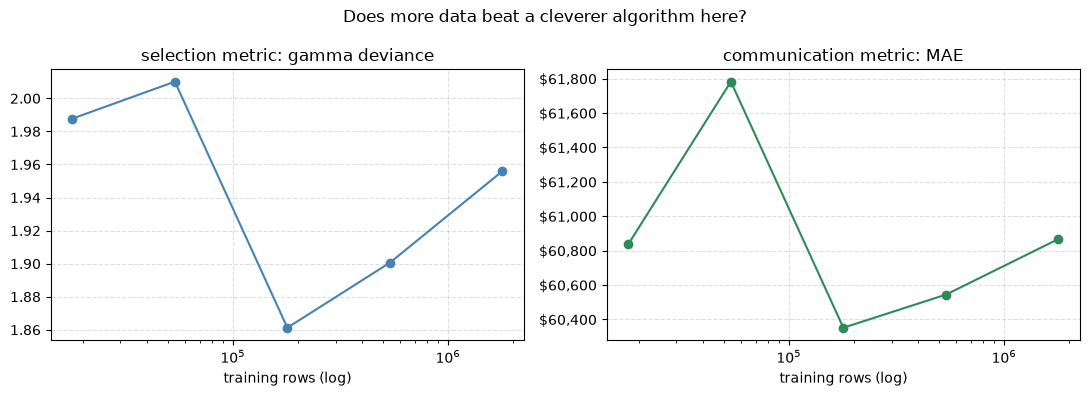

In [339]:
# more data vs a cleverer algorithm -> GBM capacity curve on the FIXED OOT test
# Companion to the flat tuning surface above: two independent probes of the
# same question. 
# > Read on gamma deviance (selection)
# > MAE shown for dollars
from sklearn.base import clone

fracs = [0.01, 0.03, 0.10, 0.30, 1.00]
rng = np.random.default_rng(RANDOM_STATE)
idx = np.arange(len(X_train))
curve = []
for f in fracs:
    take = rng.choice(idx, size=max(500, int(f * len(idx))), replace=False)
    m = clone(gbm).fit(X_train.iloc[take], y_train[take])
    pr = clip_at_coverage(m.predict(X_test), X_test)
    curve.append(
        {
            "train rows": len(take),
            "gamma deviance": mean_gamma_deviance(y_test, np.maximum(pr, DEV_FLOOR)),
            "MAE ($)": mean_absolute_error(y_test, pr),
        }
    )
curve_df = pd.DataFrame(curve).set_index("train rows")
print(curve_df.round(3).to_string())

import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
curve_df["gamma deviance"].plot(marker="o", logx=True, ax=ax1, color="steelblue")
ax1.set_title("selection metric: gamma deviance")
ax1.set_xlabel("training rows (log)")
curve_df["MAE ($)"].plot(marker="o", logx=True, ax=ax2, color="seagreen")
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax2.set_title("communication metric: MAE")
ax2.set_xlabel("training rows (log)")
for ax in (ax1, ax2):
    ax.grid(linestyle="--", alpha=0.4)
fig.suptitle("Does more data beat a cleverer algorithm here?")
plt.tight_layout()
plt.show()

- More data -> better deviance & lower MAE

In [340]:
# tuning before-and-after — now a three-step arc for Reflection 8:
#   default -> MAE-tuned (the SYMPTOM: flat/better MAE, worse deviance)
#           -> deviance-tuned (the FIX: selected on the mean-consistent metric)
# The MAE-scored winner is rebuilt from the archived cache record; the row is
# skipped gracefully if no archive exists (e.g. a fresh clone of the repo).
rows = [
    score_row(
        "GLM default (alpha=3)", y_test, clip_at_coverage(glm.predict(X_test), X_test)
    ),
    score_row(
        f"GLM tuned (alpha={glm_best.named_steps['glm'].alpha:g}, deviance-scored)",
        y_test,
        clip_at_coverage(glm_best.predict(X_test), X_test),
    ),
    score_row("GBM default", y_test, clip_at_coverage(gbm.predict(X_test), X_test)),
]

old = cache.get(f"{mode_key}_superseded_mae")
if old:
    # one extra fit at the archived MAE-scored params (~5-15 min full data)
    gbm_mae = clone(gbm).set_params(**_best_params(old, "gbm")).fit(X_train, y_train)
    rows.append(
        score_row(
            "GBM tuned (MAE-scored - R8 symptom)",
            y_test,
            clip_at_coverage(gbm_mae.predict(X_test), X_test),
        )
    )
else:
    print("note: no archived MAE-scored record - symptom row skipped")

rows.append(
    score_row(
        "GBM tuned (deviance-scored - R8 fix)",
        y_test,
        clip_at_coverage(gbm_best.predict(X_test), X_test),
    )
)

before_after = pd.DataFrame(rows).set_index("Model")
print(before_after.round(3).to_string())

d = before_after["D2 (gamma)"]
if old:
    print(
        f"\nGBM D2 (gamma): default {d['GBM default']:.3f} -> "
        f"MAE-tuned {d['GBM tuned (MAE-scored - R8 symptom)']:.3f} -> "
        f"deviance-tuned {d['GBM tuned (deviance-scored - R8 fix)']:.3f}"
        "   (symptom -> fix, in one line)"
    )

                                          MAE ($)    RMSE ($)     R2  D2 (gamma)
Model                                                                           
GLM default (alpha=3)                   64365.164  158406.626 -0.011      -0.052
GLM tuned (alpha=0.1, deviance-scored)  63850.865  155612.204  0.024       0.014
GBM default                             61041.919  153452.220  0.051      -0.087
GBM tuned (MAE-scored - R8 symptom)     61695.793  153811.299  0.046      -0.112
GBM tuned (deviance-scored - R8 fix)    60761.654  153188.177  0.054      -0.124

GBM D2 (gamma): default -0.087 -> MAE-tuned -0.112 -> deviance-tuned -0.124   (symptom -> fix, in one line)


## 13. Interpretation: SHAP

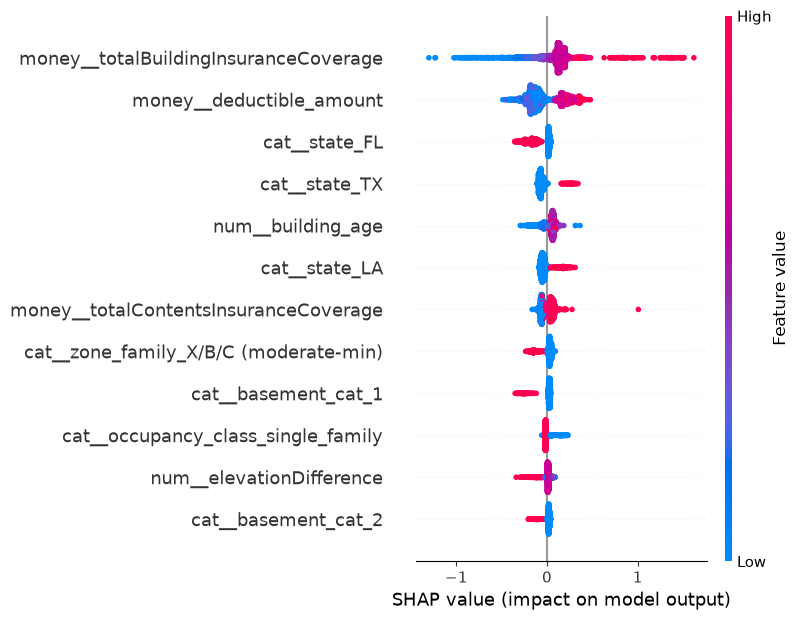

In [341]:
# SHAP on the OUT-OF-TIME TEST rows.
# BE note: updated from 500 TRAINING rows to 2000 to unseen claims
N_SHAP = min(2_000, len(X_test))
X_shap_raw = X_test.sample(N_SHAP, random_state=RANDOM_STATE)
Xt = best_model.named_steps["prep"].transform(X_shap_raw)
feature_names = best_model.named_steps["prep"].get_feature_names_out()
explainer = shap.TreeExplainer(best_model.named_steps["gbm"])
shap_values = explainer.shap_values(Xt)
shap.summary_plot(shap_values, Xt, feature_names=feature_names, max_display=12)

In [342]:
# Get importance ranking
# mean absolute SHAP value
importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)
print("Top drivers (mean |SHAP|):")
print(importance.to_string())

Top drivers (mean |SHAP|):
money__totalBuildingInsuranceCoverage    0.213381
money__deductible_amount                 0.171982
cat__state_FL                            0.109831
cat__state_TX                            0.073448
num__building_age                        0.064930
cat__state_LA                            0.056461
money__totalContentsInsuranceCoverage    0.051703
cat__zone_family_X/B/C (moderate-min)    0.051050
cat__basement_cat_1                      0.036864
cat__occupancy_class_single_family       0.032569


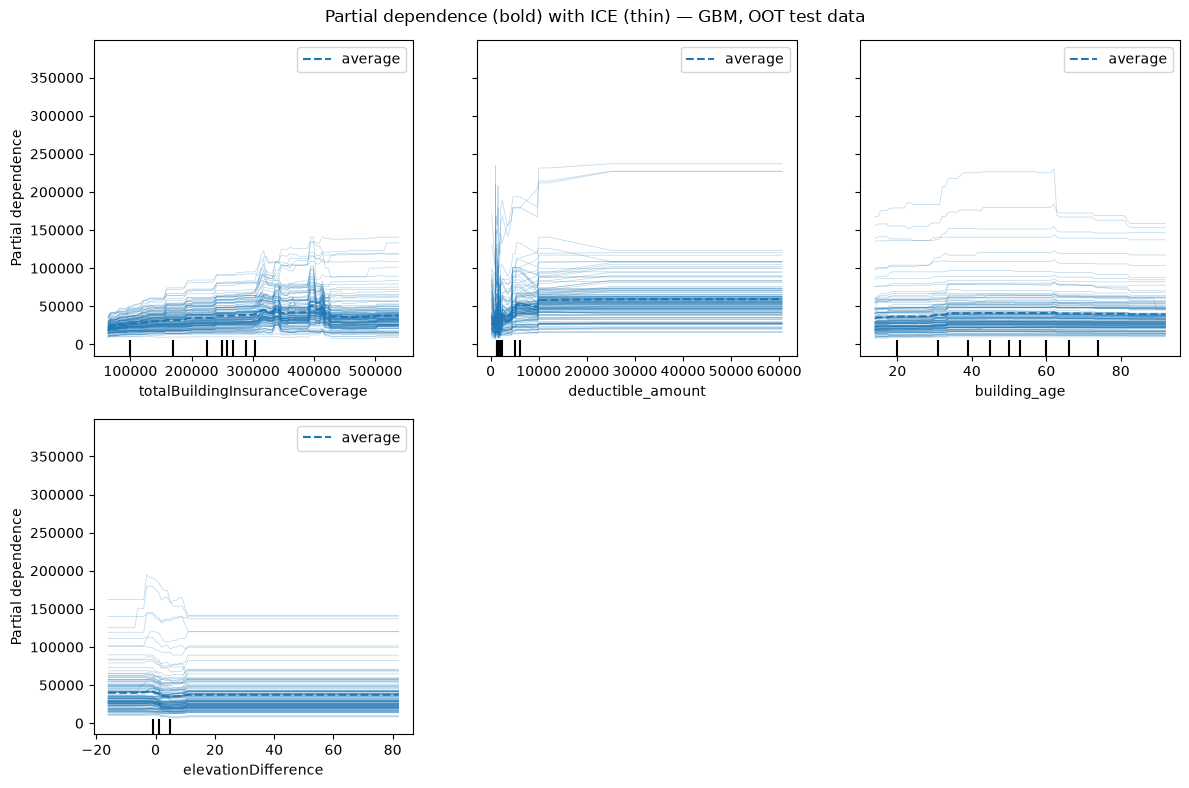

In [343]:
# partial dependence + ICE, raw feature space (x-axes in real units).
# Sync PDP_FEATURES with the top NUMERIC drivers from the permutation table.
from sklearn.inspection import PartialDependenceDisplay

PDP_FEATURES = [
    "totalBuildingInsuranceCoverage",
    "deductible_amount",
    "building_age",
    "elevationDifference",
]  # <- sync with 1a
X_pdp = X_test.sample(min(5_000, len(X_test)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_model,
    X_pdp,
    features=PDP_FEATURES,
    kind="both",
    subsample=150,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    ax=ax,
)
fig.suptitle("Partial dependence (bold) with ICE (thin) — GBM, OOT test data")
plt.tight_layout()
plt.show()

In [344]:
# GLM coefficients as multiplicative severity effects (log link => exp(beta)).
# Uses glm_best (alpha=0.03 from the Section 12 search; per Reflection 8 that
# search was MAE-scored - a caveat on alpha's optimality, not on the reading
# of the coefficients themselves).
# CAVEATS for the markdown below the table:
#  - numerics are standardised (money also log1p'd): exp(beta) is the
#    multiplier for +1 SD of the TRANSFORMED feature, not +$1;
#  - one-hot keeps all categories: effects are relative to the regularised
#    average, not a named reference level;
#  - regularisation shrinks: read direction and relative size, not gospel.
names = glm_best.named_steps["prep"].get_feature_names_out()
coefs = glm_best.named_steps["glm"].coef_
coef_df = (
    pd.DataFrame({"feature": names, "beta": coefs})
    .assign(**{"exp(beta) multiplier": lambda d: np.exp(d["beta"])})
    .sort_values("beta", key=np.abs, ascending=False)
)
print(coef_df.head(15).round(3).to_string(index=False))

                               feature   beta  exp(beta) multiplier
                         cat__state_LA  0.287                 1.332
    cat__occupancy_class_single_family -0.218                 0.804
 money__totalBuildingInsuranceCoverage  0.217                 1.243
                         cat__state_TX  0.208                 1.231
                         cat__state_MS  0.154                 1.166
                   cat__basement_cat_1 -0.144                 0.866
  cat__occupancy_class_non_residential  0.143                 1.154
     cat__occupancy_class_multi_family  0.132                 1.141
                         cat__state_FL -0.111                 0.895
             cat__basement_cat_missing  0.111                 1.118
    num__missingindicator_building_age -0.108                 0.898
                   cat__basement_cat_0  0.103                 1.108
                   cat__basement_cat_2 -0.102                 0.903
                     num__building_age  0.088   

### Segmented error analysis

In [345]:
# segmented error analysis - where does the model fail, and in which direction?
# Reuses the clipped preds_oot (Reflection 5 frame); deviance uses DEV_FLOOR.
# err > 0 = over-prediction (lost quotes); err < 0 = under-prediction
# (under-reserving - the direction a catastrophe reinsurer fears).
p = preds_oot["GBM (gamma loss)"]
seg = pd.DataFrame(
    {
        "y": np.asarray(y_test, float),
        "yhat": np.asarray(p, float),
        "state": X_test["state"].to_numpy(),
        "zone": X_test["zone_family"].to_numpy(),
        "year": years[is_test].astype(int),
    }
)
seg["err"] = seg["yhat"] - seg["y"]
seg["ratio"] = seg["yhat"] / seg["y"]
seg["band"] = pd.qcut(
    seg["y"], [0, 0.5, 0.9, 0.99, 1.0], labels=["<=p50", "p50-p90", "p90-p99", "top 1%"]
)


def seg_table(g):
    return pd.Series(
        {
            "n": len(g),
            "MAE ($)": g["err"].abs().mean(),
            "median bias ($)": g["err"].median(),
            "median pred/actual": g["ratio"].median(),
            "share under-predicted": (g["err"] < 0).mean(),
            "gamma deviance": mean_gamma_deviance(
                g["y"], np.maximum(g["yhat"], DEV_FLOOR)
            ),
        }
    )


print("--- by claim-size band (the tail question) ---")
band_tbl = seg.groupby("band", observed=True).apply(seg_table)
print(band_tbl.round(2).to_string())

print("\n--- by loss year (drift vs the Reflection 3 maturity story) ---")
print(seg.groupby("year").apply(seg_table).round(2).to_string())

print("\n--- by zone family ---")
zone_tbl = seg.groupby("zone").apply(seg_table)
print(zone_tbl.round(2).to_string())

print("\n--- by state (top 10 by test-claim count) ---")
top_states = seg["state"].value_counts().head(10).index
state_tbl = (
    seg[seg["state"].isin(top_states)]
    .groupby("state")
    .apply(seg_table)
    .sort_values("median bias ($)")
)
print(state_tbl.round(2).to_string())

top = seg[seg["band"] == "top 1%"]
print(
    f"\nTop-1% claims (n={len(top):,}): {(top['err'] < 0).mean():.0%} under-predicted; "
    f"mean shortfall on those ${-top.loc[top['err'] < 0, 'err'].mean():,.0f}; "
    f"median pred/actual {top['ratio'].median():.2f}"
)

--- by claim-size band (the tail question) ---
                n    MAE ($)  median bias ($)  median pred/actual  share under-predicted  gamma deviance
band                                                                                                    
<=p50    106873.0   21353.34         16348.38                2.61                   0.15            1.30
p50-p90   85498.0   57307.83        -51190.28                0.41                   0.94            1.63
p90-p99   19237.0  200132.94       -189300.65                0.20                   1.00            5.73
top 1%     2138.0  942800.80       -595747.07                0.15                   1.00           10.73

--- by loss year (drift vs the Reflection 3 maturity story) ---
            n   MAE ($)  median bias ($)  median pred/actual  share under-predicted  gamma deviance
year                                                                                               
2020  24010.0  34759.63         12258.93                1.

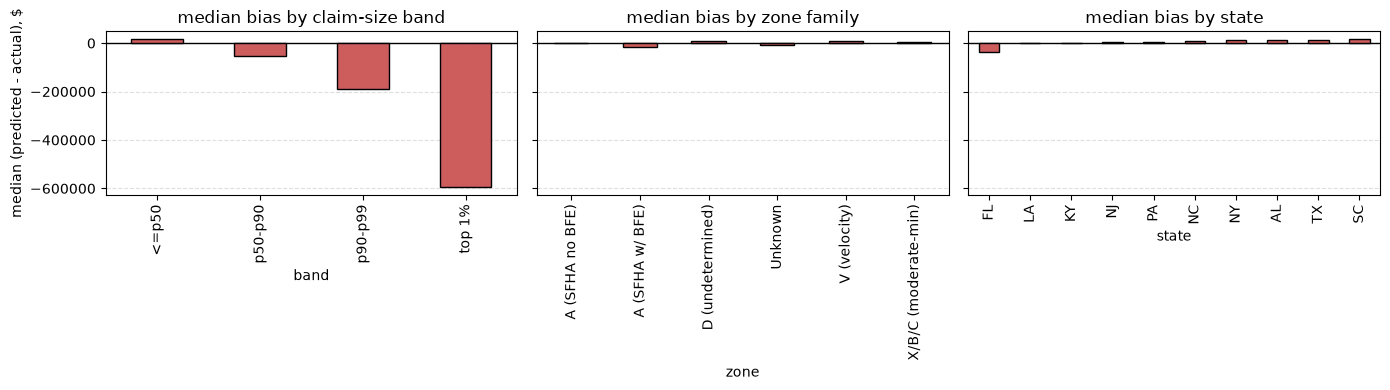

In [346]:
# small-multiple: median bias by segment (below zero = under-prediction)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (col, tbl) in zip(
    axes,
    [("claim-size band", band_tbl), ("zone family", zone_tbl), ("state", state_tbl)],
):
    tbl["median bias ($)"].plot(
        kind="bar", ax=ax, color="indianred", edgecolor="black", zorder=3
    )
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"median bias by {col}")
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
axes[0].set_ylabel("median (predicted - actual), $")
plt.tight_layout()
plt.show()

## 14. Behavioural rider: under-insurance

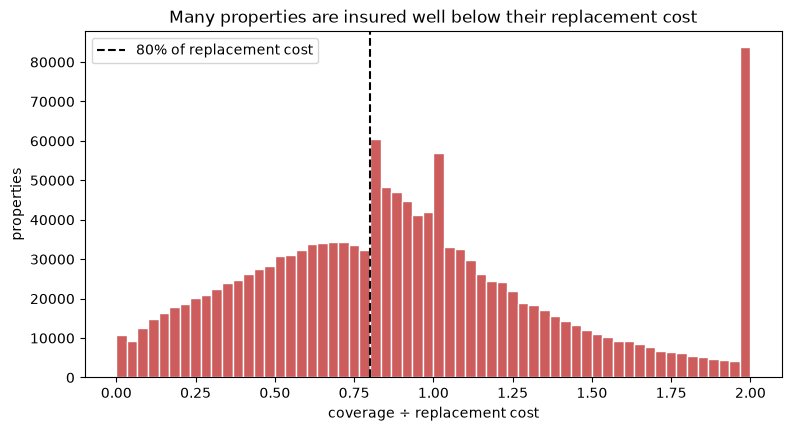

properties assessed       : 1,417,082
median coverage/replacement: 0.87
under-insured (<80%)       : 42%
severely under-insured(<50%): 21%


In [347]:
# behaviour explore
# coverage vs replacement cost - just where both are present
rc = pd.to_numeric(model_df["buildingReplacementCost"], errors="coerce")
cov = model_df["totalBuildingInsuranceCoverage"]
ok = rc.notna() & cov.notna() & (rc > 0)
ratio = (cov[ok] / rc[ok]).clip(upper=2)  # coverage as a fraction of replacement cost

plt.hist(ratio, bins=60, color="indianred", edgecolor="white")
plt.axvline(0.8, color="black", ls="--", label="80% of replacement cost")
plt.xlabel("coverage ÷ replacement cost")
plt.ylabel("properties")
plt.legend()
plt.title("Many properties are insured well below their replacement cost")
plt.show()

print(f"properties assessed       : {int(ok.sum()):,}")
print(f"median coverage/replacement: {ratio.median():.2f}")
print(f"under-insured (<80%)       : {(ratio < 0.8).mean():.0%}")
print(f"severely under-insured(<50%): {(ratio < 0.5).mean():.0%}")

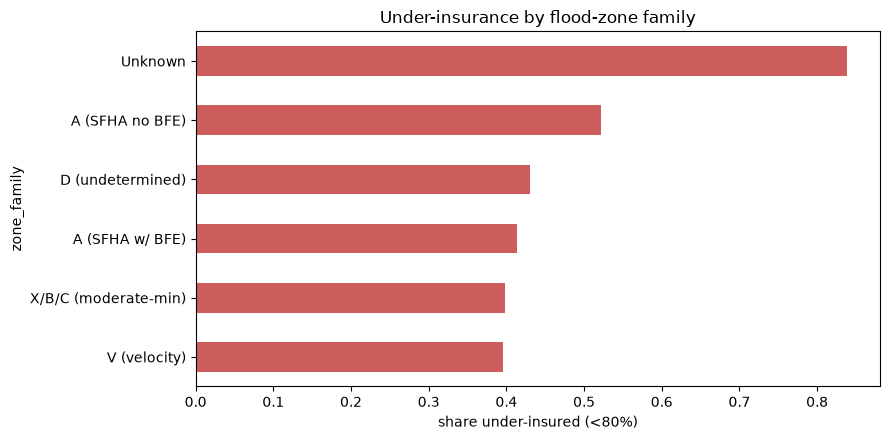

In [348]:
# Which segments are most under-insured? (share below 80% of replacement cost, by flood zone)
ui_share = (ratio < 0.8).groupby(model_df.loc[ok, "zone_family"]).mean().sort_values()
ui_share.plot(kind="barh", color="indianred")
plt.xlabel("share under-insured (<80%)")
plt.title("Under-insurance by flood-zone family")
plt.tight_layout()
plt.show()

## 15. What this means for pricing

In [349]:
# Model-implied severity for every modelled property, vs the flat zone-average
# it is priced at today

# within-zone dispersion on the OOT TEST rows only -> coverage-clipped
test_df = model_df.loc[is_test].copy()
test_df["pred_severity"] = clip_at_coverage(best_model.predict(X[is_test]), X[is_test])
zone = test_df["zone_family"].value_counts().idxmax()
sub = test_df[test_df["zone_family"] == zone]
# what flat zone pricing charges everyone here
zone_flat = sub["amountPaidOnBuildingClaim"].mean()
deciles = sub["pred_severity"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(0)

print(f"Largest zone: {zone}  (flat zone severity = ${zone_flat:,.0f})")
print("Model-implied severity within this zone (deciles):")
print(deciles.to_string())
rel = deciles / zone_flat
print("\nImplied relativity to the flat zone rate:")
print(rel.round(2).to_string())
print(
    f"\n=> Within this zone the top-decile risk carries ~{rel.loc[0.9]:.1f}x the flat "
    f"zone rate, and ~{deciles.loc[0.9] / deciles.loc[0.1]:.1f}x the bottom-decile "
    f"risk — differentiation the flat rate misses."
)

Largest zone: A (SFHA w/ BFE)  (flat zone severity = $86,220)
Model-implied severity within this zone (deciles):
0.10    19596.0
0.25    25938.0
0.50    34255.0
0.75    48512.0
0.90    64304.0

Implied relativity to the flat zone rate:
0.10    0.23
0.25    0.30
0.50    0.40
0.75    0.56
0.90    0.75

=> Within this zone the top-decile risk carries ~0.7x the flat zone rate, and ~3.3x the bottom-decile risk — differentiation the flat rate misses.


## Ethical and practical limitations

## Conclusions and recommendation

## Appendix

### GenAI usage statement

> This is attached separately